# Credit Scoring Model
## Exploratory Data Analysis (EDA)

This notebook performs an initial exploratory data analysis for the German Credit dataset. The goal is to understand the structure of the data, inspect data quality, and identify patterns in the target variable before any modeling work begins.

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

np.random.seed(42)

## 2. Load Dataset

In [5]:
from pathlib import Path

data_path = Path('../data/processed/german_credit_processed.csv')
df = pd.read_csv(data_path)

print('Shape of the dataset:')
print(df.shape)
print('\nSample of 5 rows (random):')
display(df.sample(5, random_state=42))
print('\nLast 5 rows:')
display(df.tail())

Shape of the dataset:
(1000, 21)

Sample of 5 rows (random):


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence_years,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
521,A11,18,A32,A43,3190,A61,A73,2,A92,A101,2,A121,24,A143,A152,1,A173,1,A191,A201,bad
737,A11,18,A32,A40,4380,A62,A73,3,A93,A101,4,A123,35,A143,A152,1,A172,2,A192,A201,good
740,A11,24,A31,A40,2325,A62,A74,2,A93,A101,3,A123,32,A141,A152,1,A173,1,A191,A201,good
660,A13,12,A32,A43,1297,A61,A73,3,A94,A101,4,A121,23,A143,A151,1,A173,1,A191,A201,good
411,A14,33,A34,A41,7253,A61,A74,3,A93,A101,2,A123,35,A143,A152,2,A174,1,A192,A201,good



Last 5 rows:


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence_years,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,4,A121,31,A143,A152,1,A172,1,A191,A201,good
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,4,A122,40,A143,A152,1,A174,1,A192,A201,good
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201,good
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,4,A124,23,A143,A153,1,A173,1,A192,A201,bad
999,A12,45,A34,A41,4576,A62,A71,3,A93,A101,4,A123,27,A143,A152,1,A173,1,A191,A201,good


## 3. Dataset Information

In [ ]:
print('Dataset information:')
df.info()
print('\nUnique values per column:')
print(df.nunique())
print('\nDescriptive statistics:')
display(df.describe(include='all').T)
print('\nCategorical column summaries:')
display(df.describe(include='str').T)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  1000 non-null   str  
 1   duration_months          1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence_years  1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checking_account_status,1000,4,A14,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_months,1000.00,NaN,NaN,NaN,20.90,12.06,4.00,12.00,18.00,24.00,72.00
credit_history,1000,5,A32,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,A43,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.00,NaN,NaN,NaN,3271.26,2822.74,250.00,1365.50,2319.50,3972.25,18424.00
savings_account,1000,5,A61,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_duration,1000,5,A73,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_rate,1000.00,NaN,NaN,NaN,2.97,1.12,1.00,2.00,3.00,4.00,4.00
personal_status_sex,1000,4,A93,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_debtors,1000,3,A101,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Categorical column summaries:


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\798463478.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object').T)


,count,unique,top,freq
checking_account_status,1000,4,A14,394
credit_history,1000,5,A32,530
purpose,1000,10,A43,280
savings_account,1000,5,A61,603
employment_duration,1000,5,A73,339
personal_status_sex,1000,4,A93,548
other_debtors,1000,3,A101,907
property,1000,4,A123,332
other_installment_plans,1000,3,A143,814
housing,1000,3,A152,713



Column names:
['checking_account_status', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence_years', 'property', 'age', 'other_installment_plans', 'housing', 'existing_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk']

Data types:
checking_account_status      str
duration_months            int64
credit_history               str
purpose                      str
credit_amount              int64
savings_account              str
employment_duration          str
installment_rate           int64
personal_status_sex          str
other_debtors                str
present_residence_years    int64
property                     str
age                        int64
other_installment_plans      str
housing                      str
existing_credits           int64
job                          str
people_liable              int64
telephone

## 4. Missing Values

In [7]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percentage': missing_percentage
}).sort_values(by='missing_count', ascending=False)

print('Missing values summary:')
display(missing_df[missing_df['missing_count'] > 0])

if missing_df['missing_count'].sum() > 0:
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.xlabel('Columns')
    plt.ylabel('Rows')
    plt.show()
else:
    print('No missing values found in the dataset.')

Missing values summary:


,missing_count,missing_percentage


No missing values found in the dataset.


The missing value analysis highlights whether any columns require special attention during preprocessing. In this notebook, the goal is simply to identify the extent of missingness and note whether it is negligible or significant.

## 5. Duplicate Records

In [8]:
duplicate_count = df.duplicated().sum()
print(f'Duplicate records: {duplicate_count}')

if duplicate_count > 0:
    print('Duplicate rows are present and should be reviewed before modeling.')
else:
    print('No duplicate rows were found in the dataset.')

Duplicate records: 0
No duplicate rows were found in the dataset.


Duplicate records can affect model training and evaluation if they are not handled appropriately. This section confirms whether the dataset contains repeated rows that might introduce bias.

## 6. Target Variable

Target variable counts:
credit_risk
good    700
bad     300
Name: count, dtype: int64

Target variable percentages:
credit_risk
good   70.00
bad    30.00
Name: proportion, dtype: float64


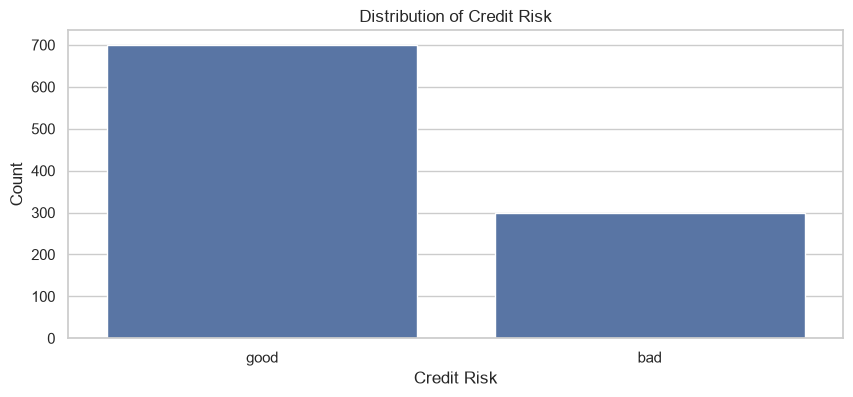

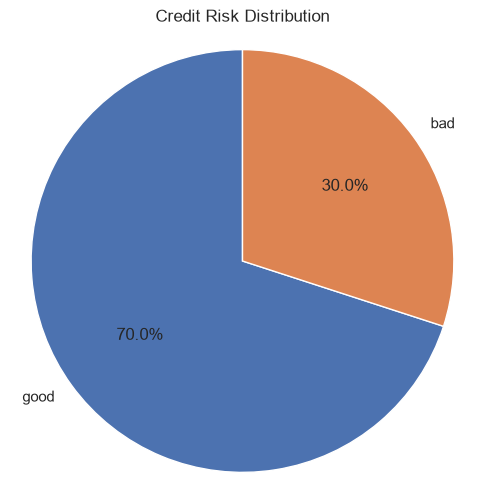

In [9]:
target_counts = df['credit_risk'].value_counts()
target_percentages = df['credit_risk'].value_counts(normalize=True) * 100

print('Target variable counts:')
print(target_counts)
print('\nTarget variable percentages:')
print(target_percentages)

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='credit_risk', order=target_counts.index)
plt.title('Distribution of Credit Risk')
plt.xlabel('Credit Risk')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 6))
plt.pie(target_percentages, labels=target_percentages.index, autopct='%1.1f%%', startangle=90)
plt.title('Credit Risk Distribution')
plt.axis('equal')
plt.show()

The target variable distribution shows whether the dataset is balanced or imbalanced. Class imbalance is important to understand because it can influence evaluation metrics and downstream modeling choices.

# 7. Univariate Feature Analysis

Univariate analysis is important because it helps us understand each feature independently before any feature engineering or model development. It highlights distribution shape, skewness, outliers, and category imbalance, which are essential for making informed and professional modeling decisions.

## Part A — Numerical Features


Feature: duration_months
count   1000.00
mean      20.90
std       12.06
min        4.00
25%       12.00
50%       18.00
75%       24.00
max       72.00
Name: duration_months, dtype: float64


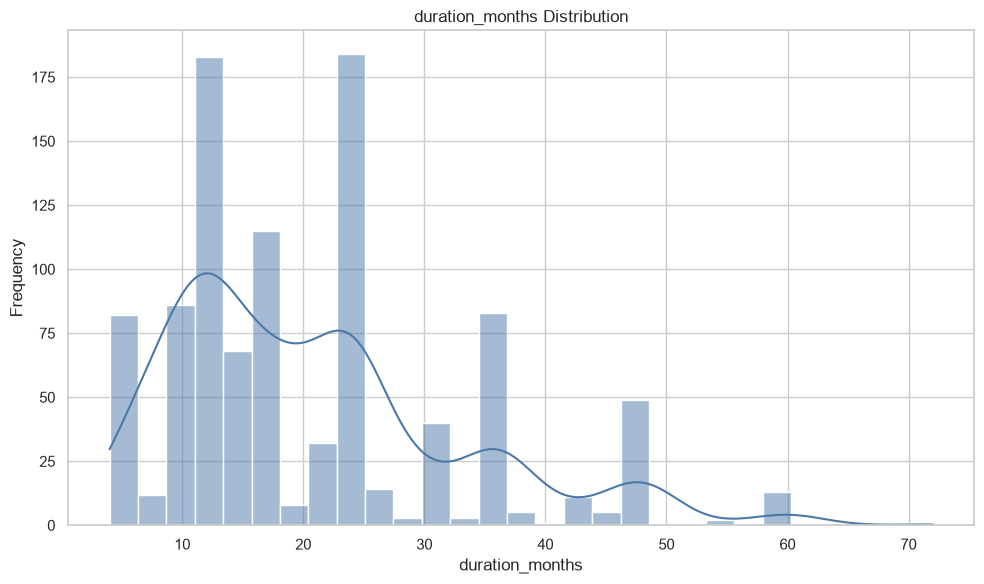

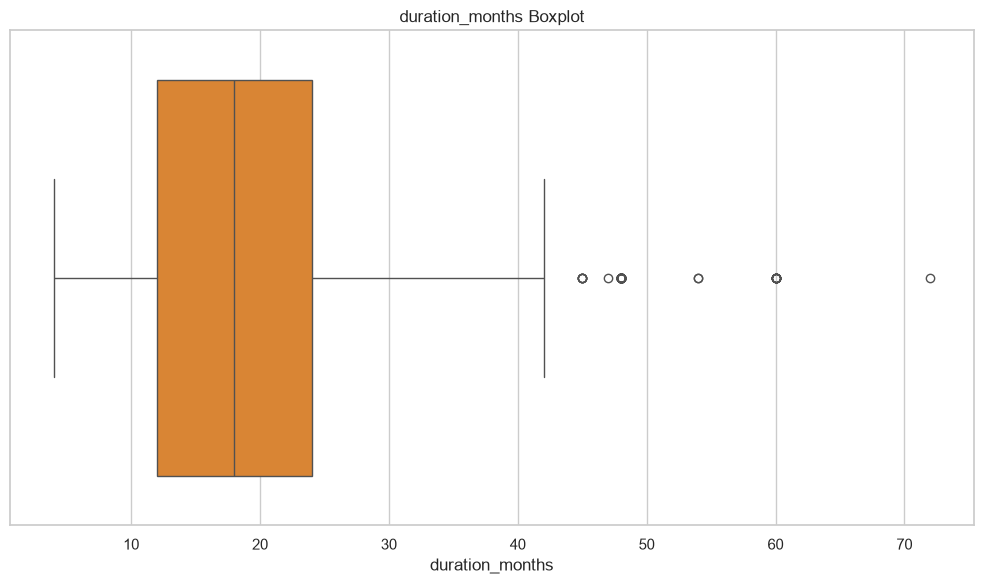

**Observation for duration_months:** The distribution may be right-skewed with a skewness of 1.09. The number of potential outliers is 70. This helps us understand the underlying financial behavior of this feature and whether its spread may affect downstream analysis.


Feature: credit_amount
count    1000.00
mean     3271.26
std      2822.74
min       250.00
25%      1365.50
50%      2319.50
75%      3972.25
max     18424.00
Name: credit_amount, dtype: float64


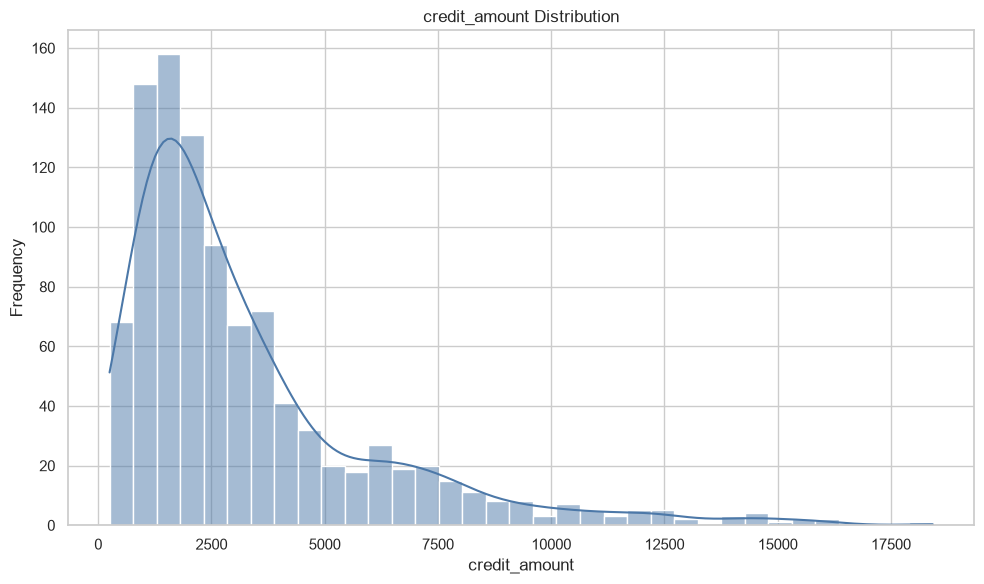

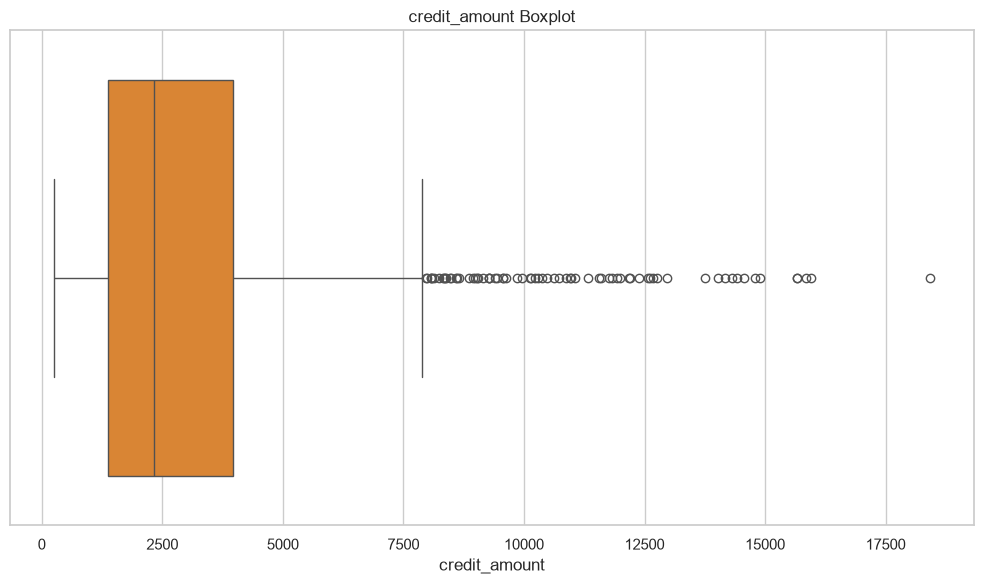

**Observation for credit_amount:** The distribution may be right-skewed with a skewness of 1.95. The number of potential outliers is 72. This helps us understand the underlying financial behavior of this feature and whether its spread may affect downstream analysis.


Feature: installment_rate
count   1000.00
mean       2.97
std        1.12
min        1.00
25%        2.00
50%        3.00
75%        4.00
max        4.00
Name: installment_rate, dtype: float64


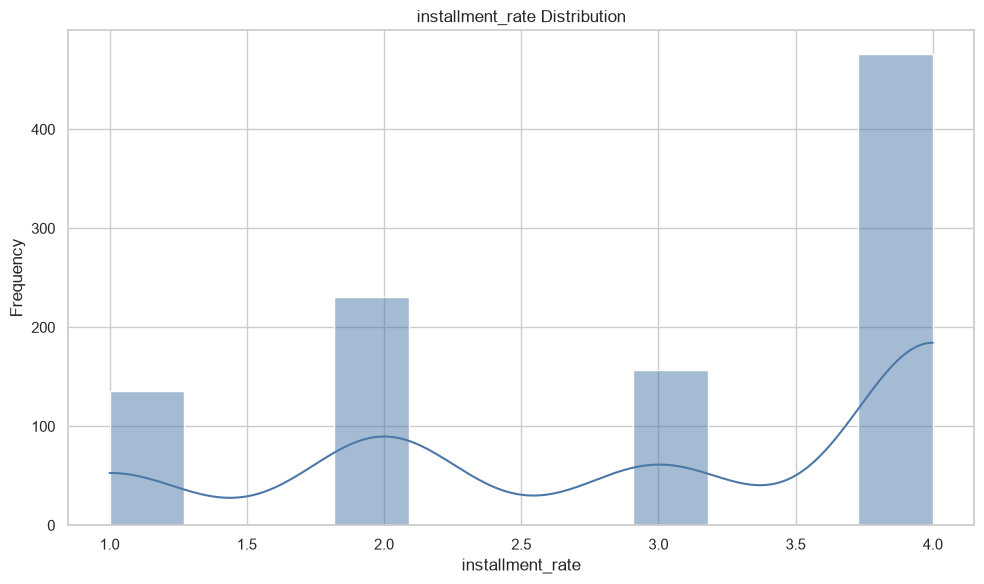

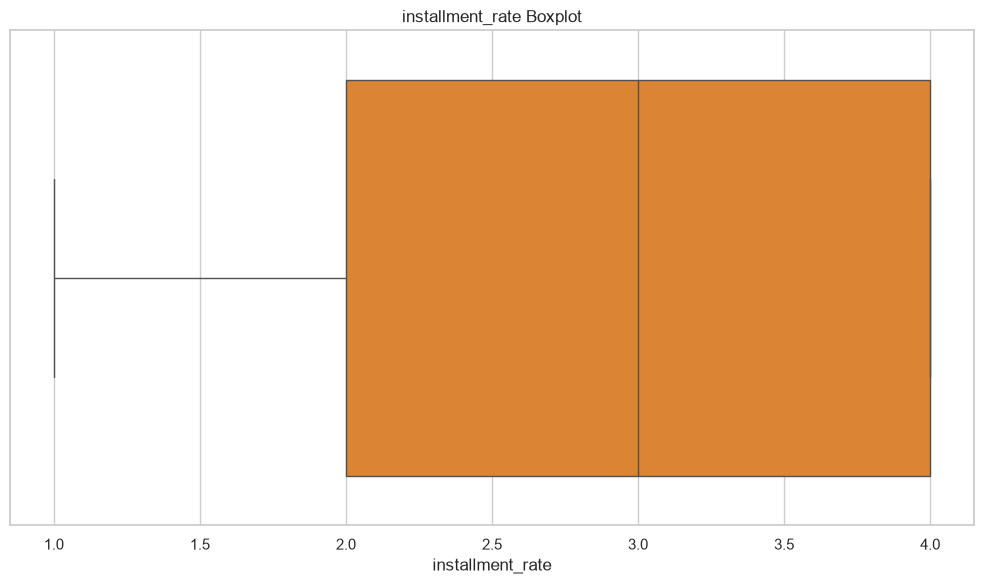

**Observation for installment_rate:** The distribution may be left-skewed with a skewness of -0.53. The number of potential outliers is 0. This helps us understand the underlying financial behavior of this feature and whether its spread may affect downstream analysis.


Feature: present_residence_years
count   1000.00
mean       2.85
std        1.10
min        1.00
25%        2.00
50%        3.00
75%        4.00
max        4.00
Name: present_residence_years, dtype: float64


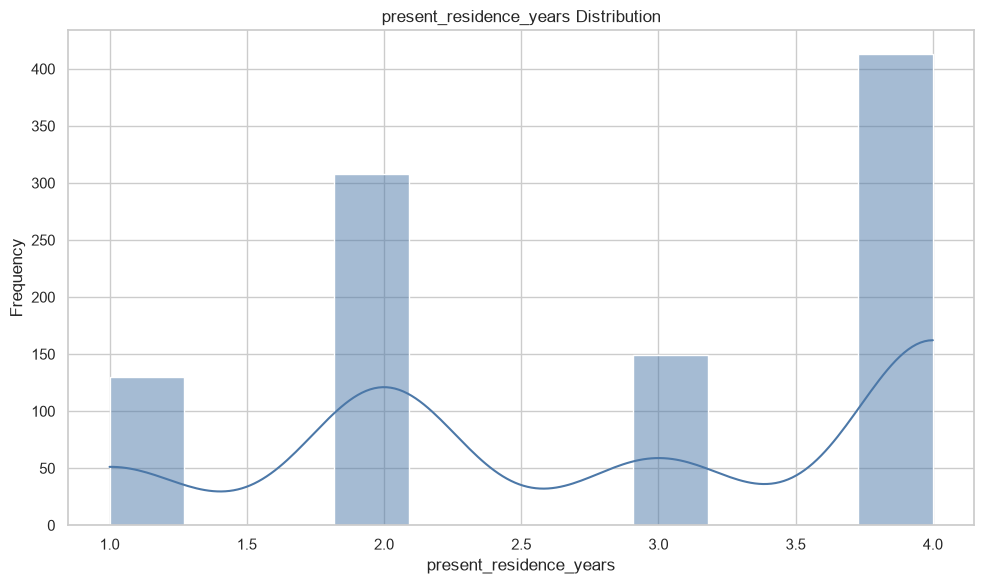

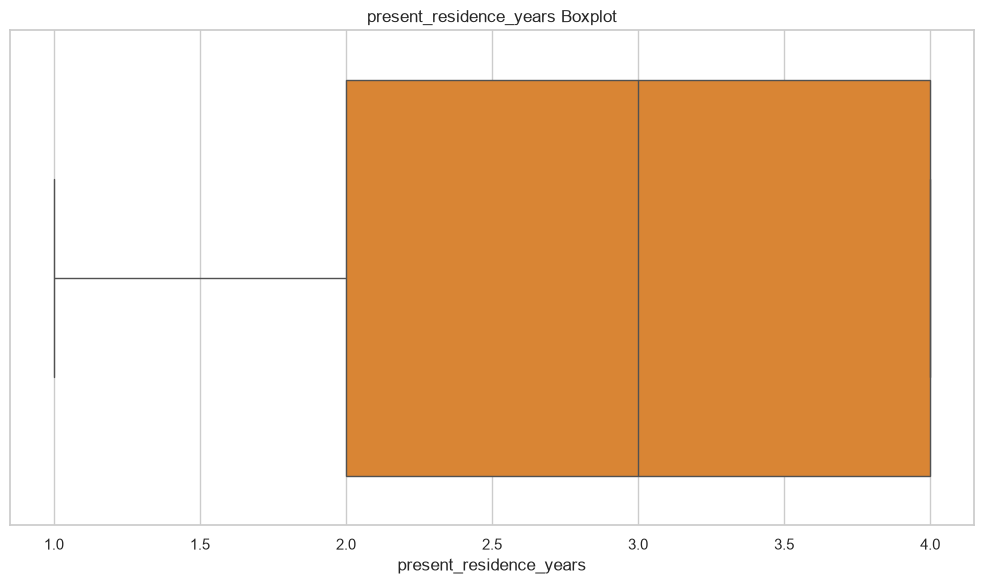

**Observation for present_residence_years:** The distribution may be approximately symmetric with a skewness of -0.27. The number of potential outliers is 0. This helps us understand the underlying financial behavior of this feature and whether its spread may affect downstream analysis.


Feature: age
count   1000.00
mean      35.55
std       11.38
min       19.00
25%       27.00
50%       33.00
75%       42.00
max       75.00
Name: age, dtype: float64


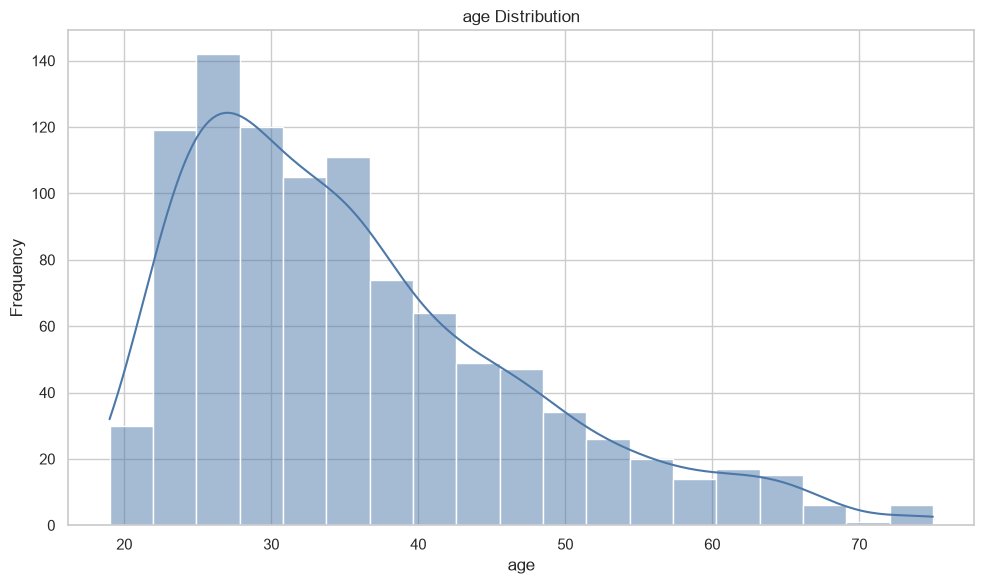

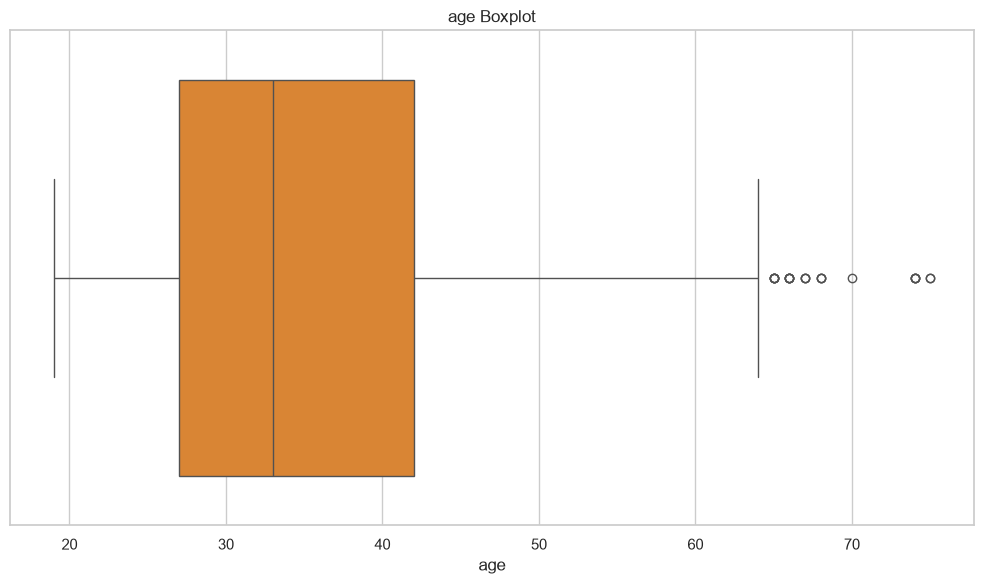

**Observation for age:** The distribution may be right-skewed with a skewness of 1.02. The number of potential outliers is 23. This helps us understand the underlying financial behavior of this feature and whether its spread may affect downstream analysis.


Feature: existing_credits
count   1000.00
mean       1.41
std        0.58
min        1.00
25%        1.00
50%        1.00
75%        2.00
max        4.00
Name: existing_credits, dtype: float64


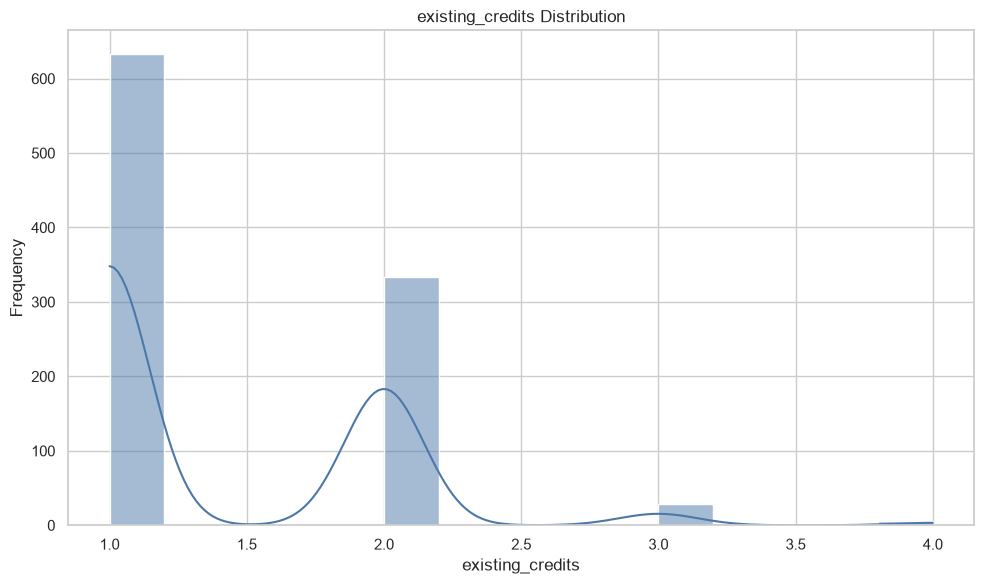

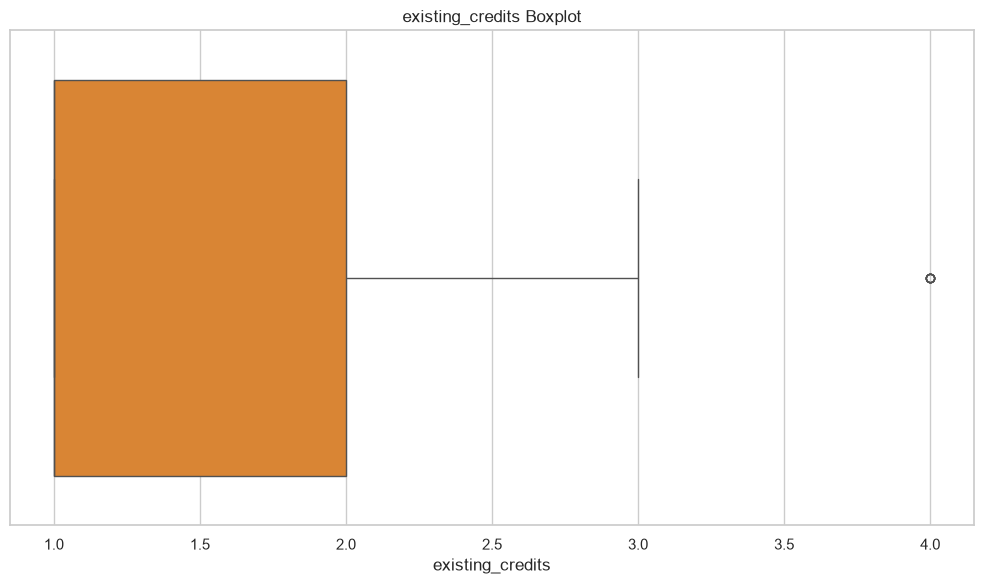

**Observation for existing_credits:** The distribution may be right-skewed with a skewness of 1.27. The number of potential outliers is 6. This helps us understand the underlying financial behavior of this feature and whether its spread may affect downstream analysis.


Feature: people_liable
count   1000.00
mean       1.16
std        0.36
min        1.00
25%        1.00
50%        1.00
75%        1.00
max        2.00
Name: people_liable, dtype: float64


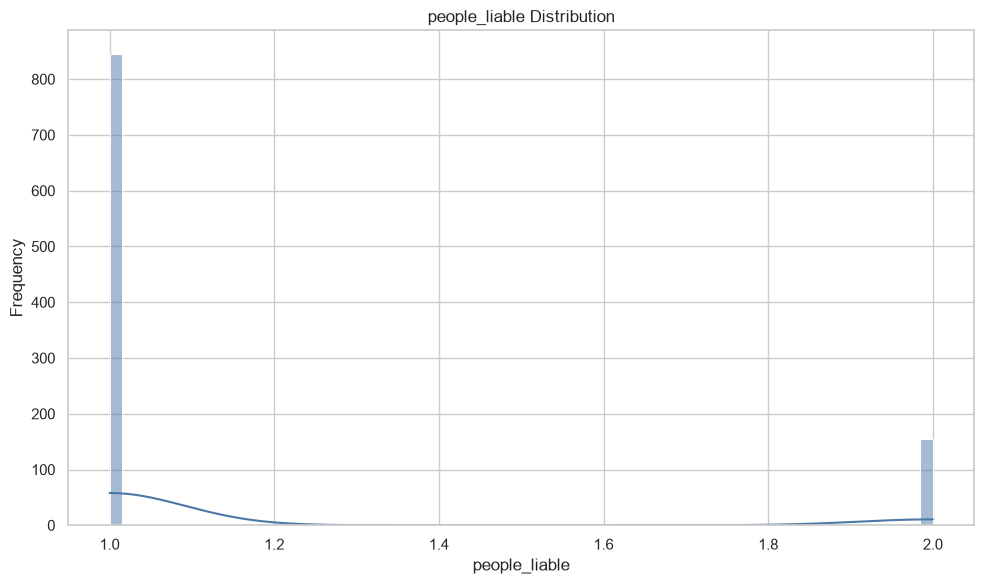

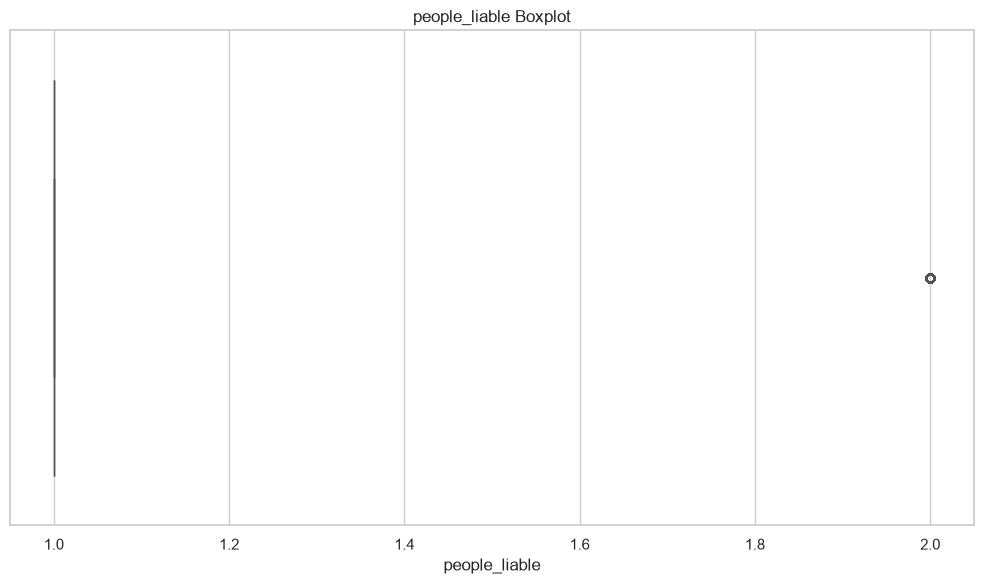

**Observation for people_liable:** The distribution may be right-skewed with a skewness of 1.91. The number of potential outliers is 155. This helps us understand the underlying financial behavior of this feature and whether its spread may affect downstream analysis.

In [ ]:
from pathlib import Path
from IPython.display import Markdown, display

output_dir = Path('../images/eda')
output_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

numeric_cols = [col for col in df.select_dtypes(include=['number']).columns if col != 'credit_risk']

for col in numeric_cols:
    print(f"\n{'=' * 60}\nFeature: {col}\n{'=' * 60}")
    print(df[col].describe())

    if col in ['installment_rate', 'people_liable', 'existing_credits', 'present_residence_years']:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=col, order=sorted(df[col].unique()), color='#4C78A8')
        plt.title(f'{col} Countplot')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.savefig(output_dir / f'{col}_countplot.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True, color='#4C78A8')
        plt.title(f'{col} Distribution')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(output_dir / f'{col}_histogram.png', dpi=300, bbox_inches='tight')
        plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[col], color='#F58518')
    plt.title(f'{col} Boxplot')
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(output_dir / f'{col}_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()

    skewness = df[col].skew()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    display(Markdown(
        f"**Observation for {col}:** The distribution may be {'right-skewed' if skewness > 0.5 else 'left-skewed' if skewness < -0.5 else 'approximately symmetric'} "
        f"with a skewness of {skewness:.2f}. The number of potential outliers is {outlier_count}. "
        f"This helps us understand the underlying financial behavior of this feature and whether its spread may affect downstream analysis."
    ))

## Part B — Categorical Features


Feature: checking_account_status


,checking_account_status,count
0,A14,394
1,A11,274
2,A12,269
3,A13,63


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


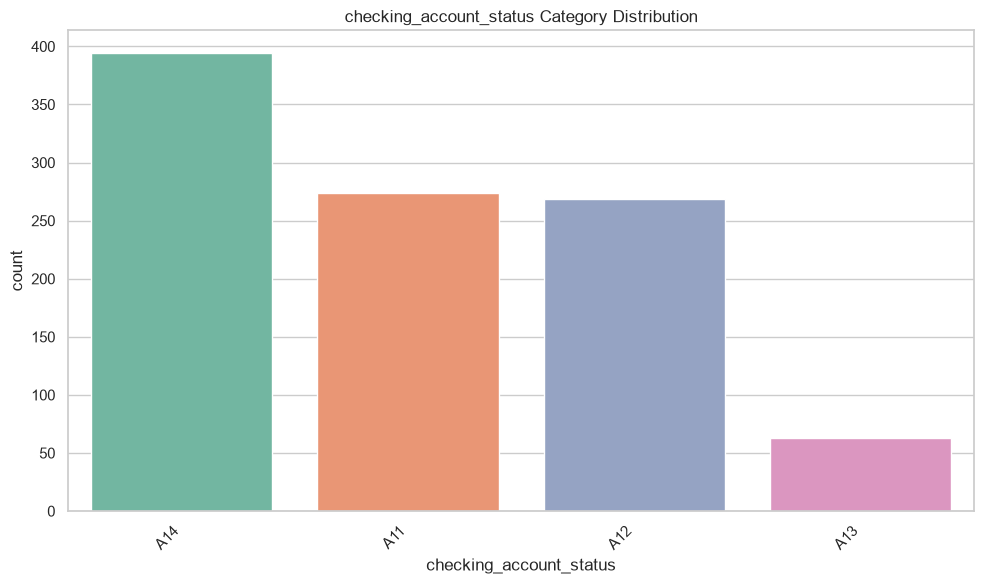

**Observation for checking_account_status:** The most frequent category is **A14** and the least frequent category is **A13**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: credit_history


,credit_history,count
0,A32,530
1,A34,293
2,A33,88
3,A31,49
4,A30,40


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


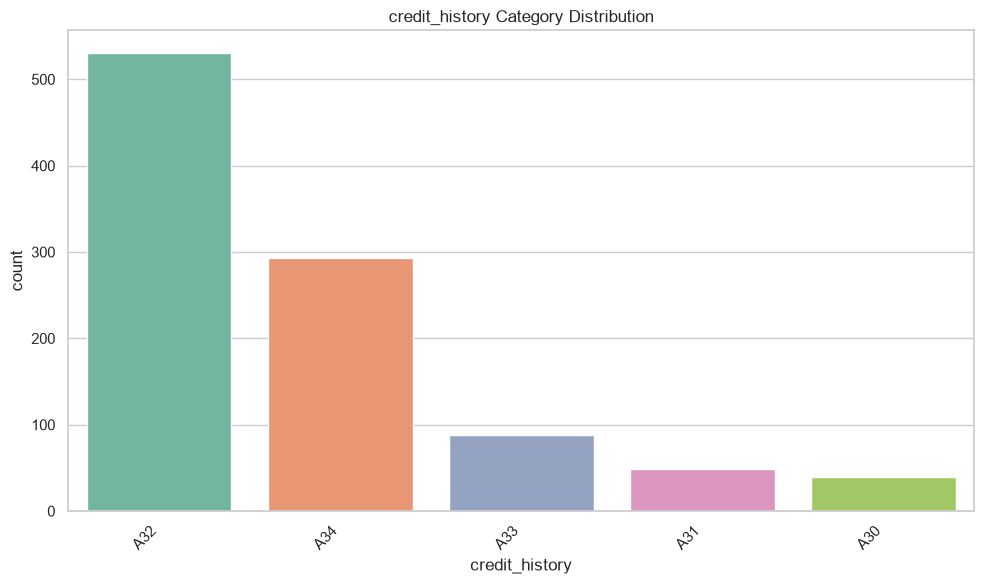

**Observation for credit_history:** The most frequent category is **A32** and the least frequent category is **A30**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: purpose


,purpose,count
0,A43,280
1,A40,234
2,A42,181
3,A41,103
4,A49,97
5,A46,50
6,A45,22
7,A44,12
8,A410,12
9,A48,9


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


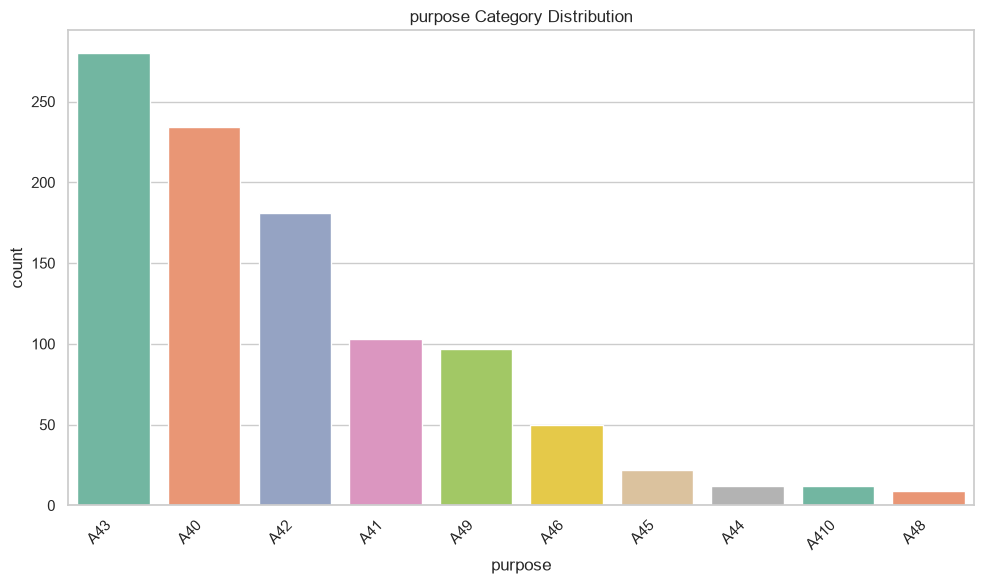

**Observation for purpose:** The most frequent category is **A43** and the least frequent category is **A48**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: savings_account


,savings_account,count
0,A61,603
1,A65,183
2,A62,103
3,A63,63
4,A64,48


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


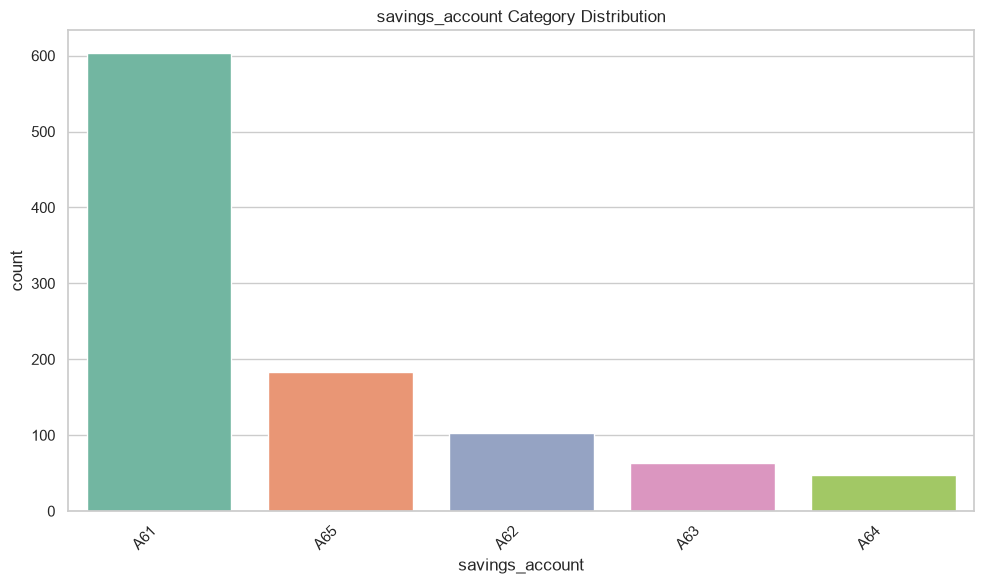

**Observation for savings_account:** The most frequent category is **A61** and the least frequent category is **A64**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: employment_duration


,employment_duration,count
0,A73,339
1,A75,253
2,A74,174
3,A72,172
4,A71,62


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


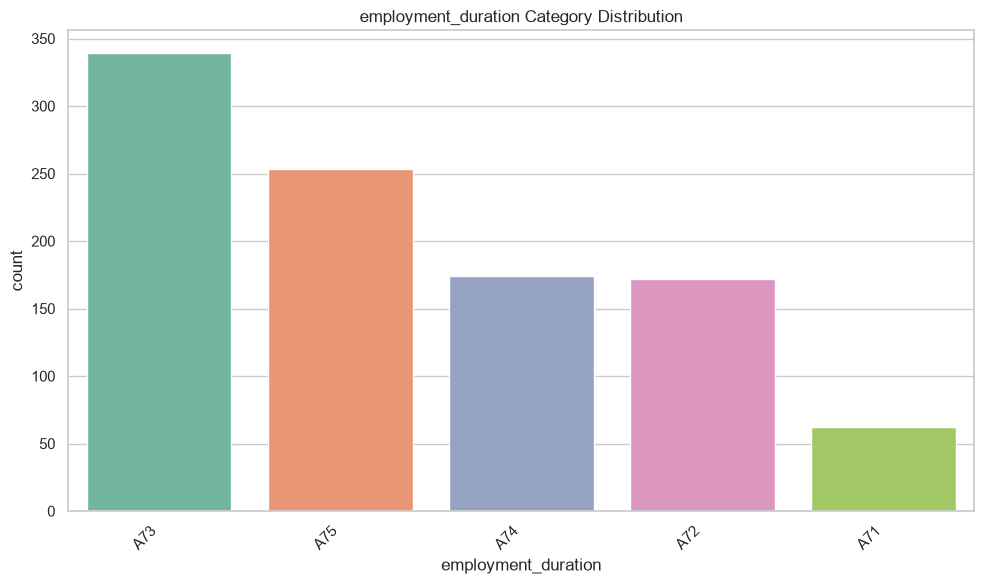

**Observation for employment_duration:** The most frequent category is **A73** and the least frequent category is **A71**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: personal_status_sex


,personal_status_sex,count
0,A93,548
1,A92,310
2,A94,92
3,A91,50


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


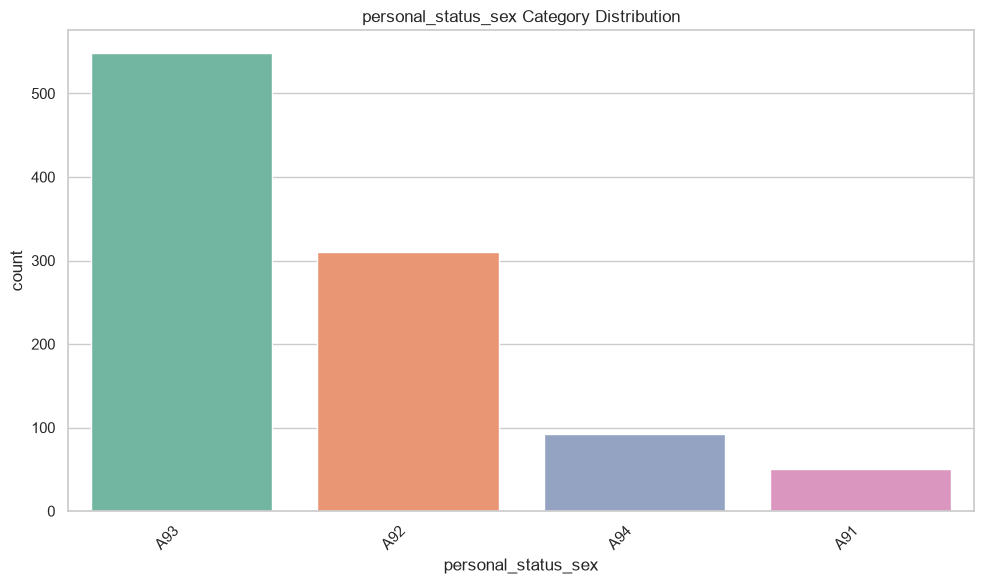

**Observation for personal_status_sex:** The most frequent category is **A93** and the least frequent category is **A91**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: other_debtors


,other_debtors,count
0,A101,907
1,A103,52
2,A102,41


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


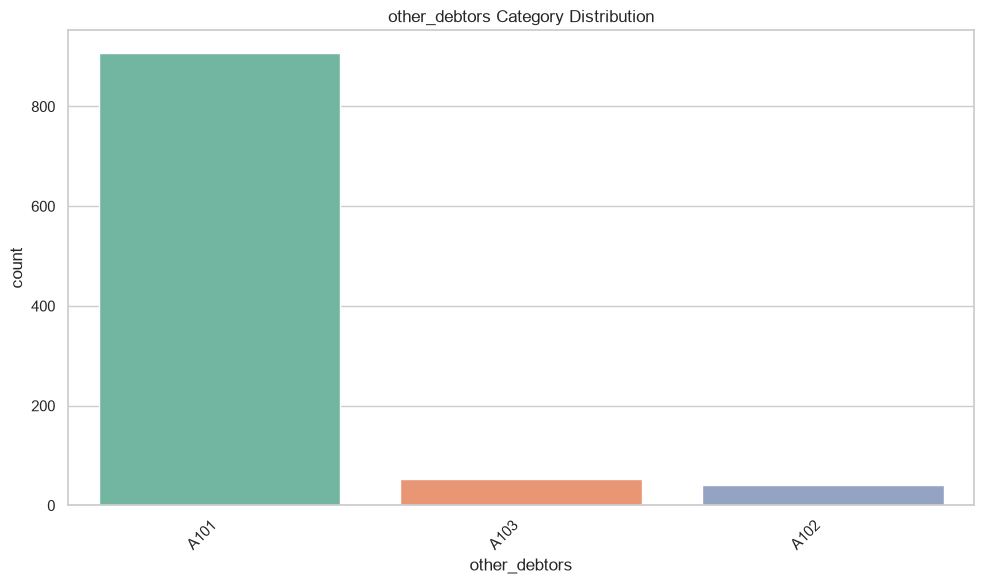

**Observation for other_debtors:** The most frequent category is **A101** and the least frequent category is **A102**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: property


,property,count
0,A123,332
1,A121,282
2,A122,232
3,A124,154


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


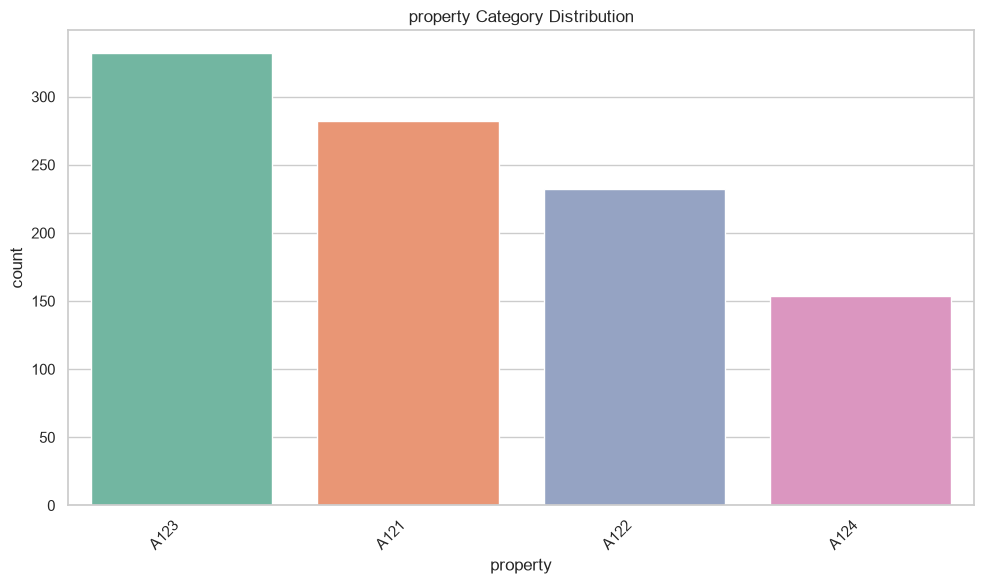

**Observation for property:** The most frequent category is **A123** and the least frequent category is **A124**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: other_installment_plans


,other_installment_plans,count
0,A143,814
1,A141,139
2,A142,47


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


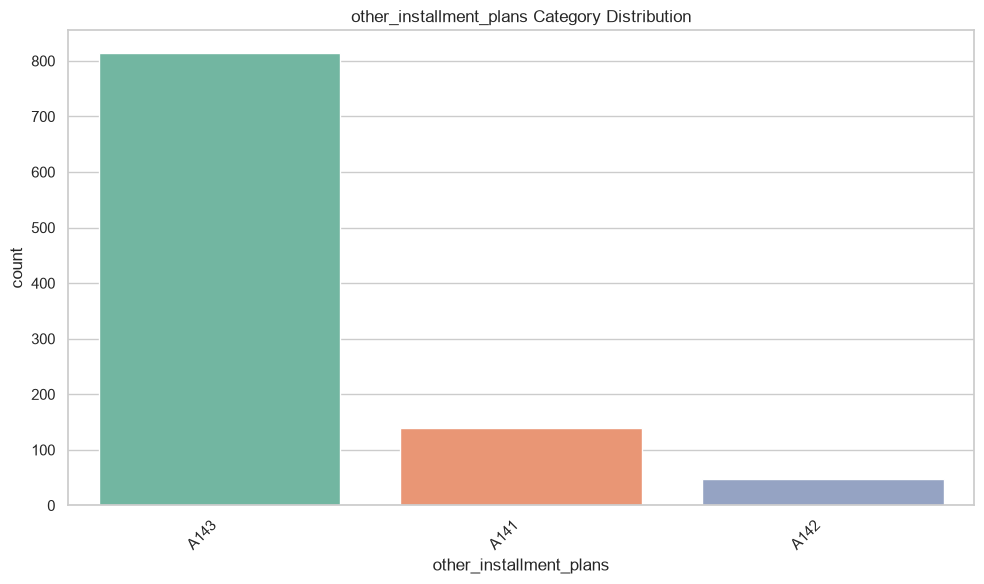

**Observation for other_installment_plans:** The most frequent category is **A143** and the least frequent category is **A142**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: housing


,housing,count
0,A152,713
1,A151,179
2,A153,108


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


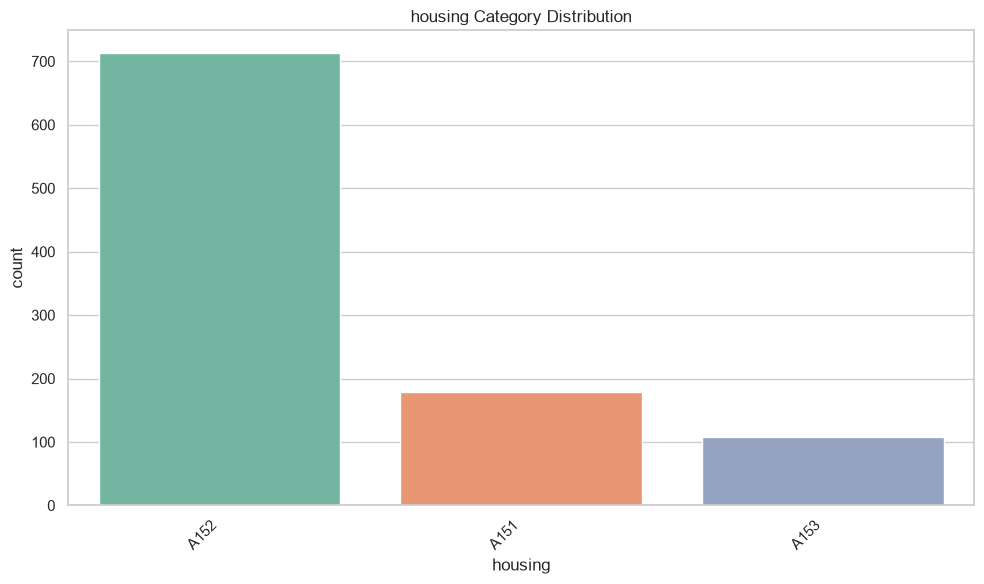

**Observation for housing:** The most frequent category is **A152** and the least frequent category is **A153**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: job


,job,count
0,A173,630
1,A172,200
2,A174,148
3,A171,22


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


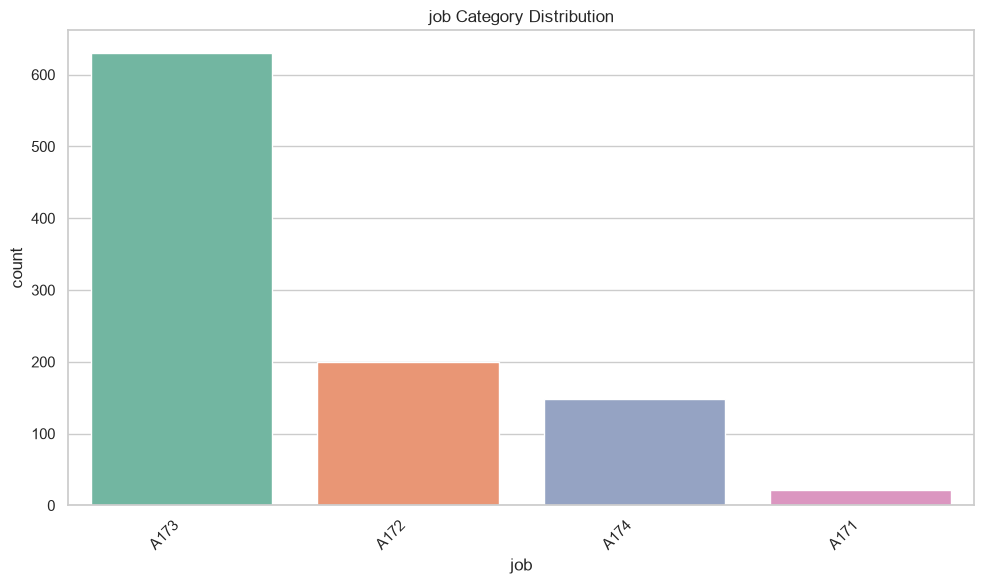

**Observation for job:** The most frequent category is **A173** and the least frequent category is **A171**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: telephone


,telephone,count
0,A191,596
1,A192,404


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


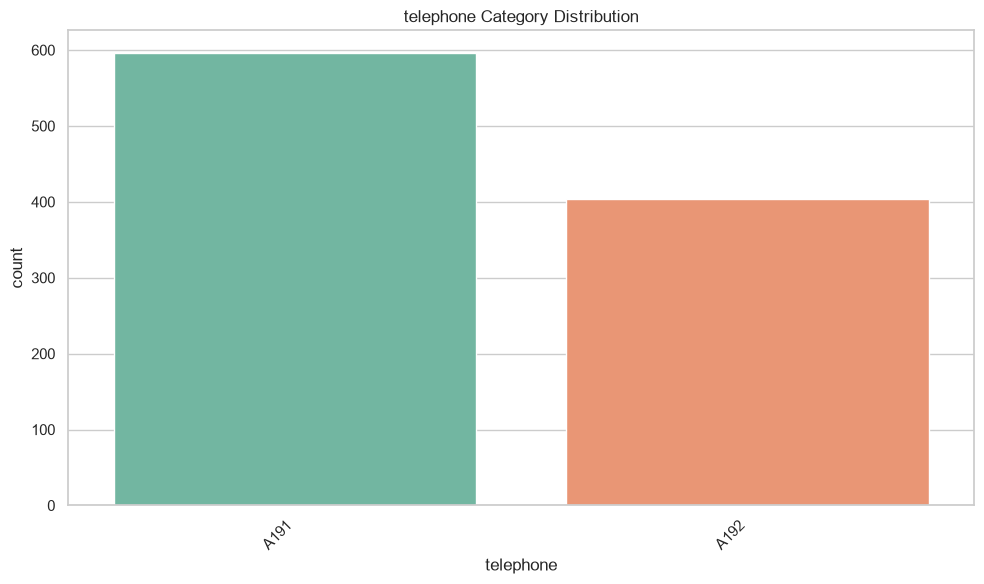

**Observation for telephone:** The most frequent category is **A191** and the least frequent category is **A192**. This highlights possible category imbalance and can provide business insight into borrower behavior.


Feature: foreign_worker


,foreign_worker,count
0,A201,963
1,A202,37


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\4189985332.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


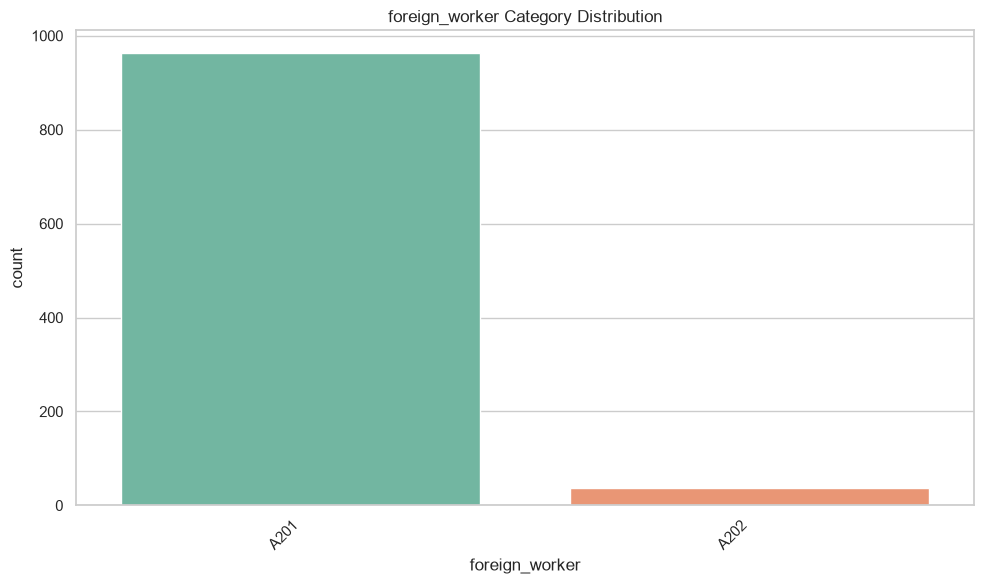

**Observation for foreign_worker:** The most frequent category is **A201** and the least frequent category is **A202**. This highlights possible category imbalance and can provide business insight into borrower behavior.

In [11]:
cat_cols = [col for col in df.select_dtypes(exclude=['number']).columns if col != 'credit_risk']

for col in cat_cols:
    print(f"\n{'=' * 60}\nFeature: {col}\n{'=' * 60}")
    freq_table = df[col].value_counts().reset_index()
    freq_table.columns = [col, 'count']
    display(freq_table)

    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')
    plt.title(f'{col} Category Distribution')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(output_dir / f'{col}_countplot.png', dpi=300, bbox_inches='tight')
    plt.show()

    most_frequent = df[col].value_counts().idxmax()
    least_frequent = df[col].value_counts().idxmin()
    display(Markdown(
        f"**Observation for {col}:** The most frequent category is **{most_frequent}** and the least frequent category is **{least_frequent}**. "
        f"This highlights possible category imbalance and can provide business insight into borrower behavior."
    ))

# 7. Bivariate Analysis

This section studies the relationship between independent variables and the target variable, credit_risk, to understand how different features vary across credit outcomes.

## 7.1 Numerical Features vs Credit Risk


Feature: age


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


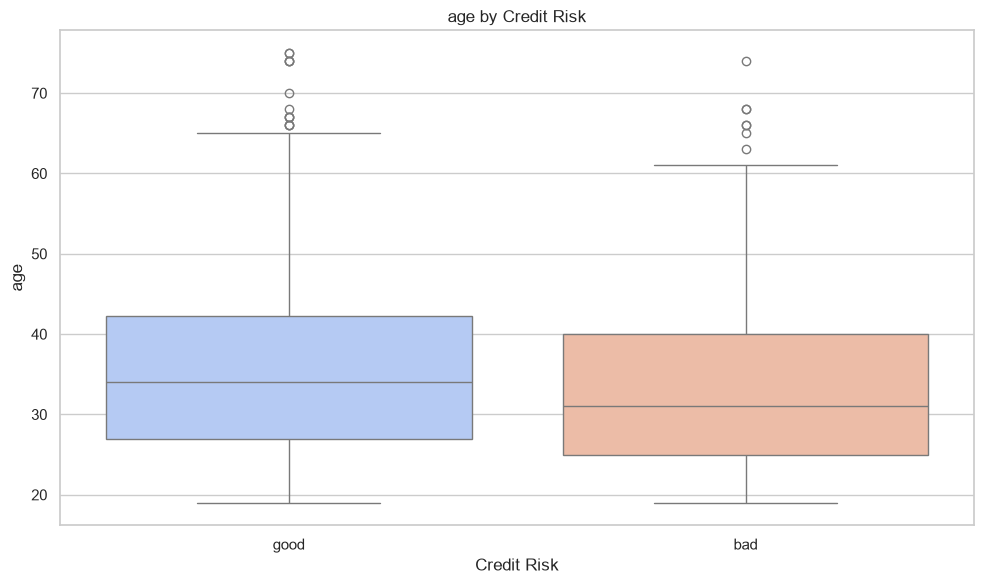

C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


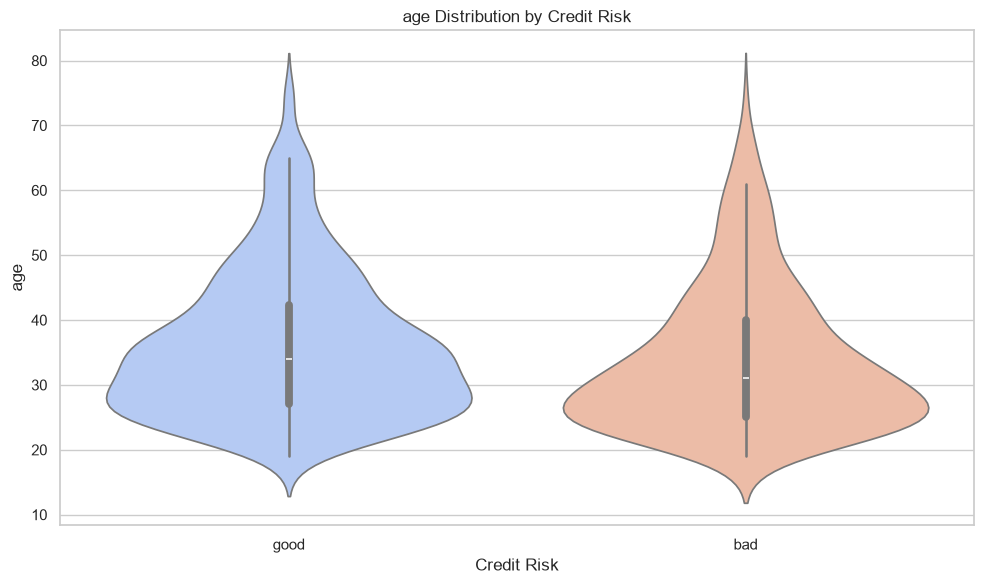

             count  mean   std   min   25%   50%   75%   max
credit_risk                                                 
bad         300.00 33.96 11.22 19.00 25.00 31.00 40.00 74.00
good        700.00 36.22 11.38 19.00 27.00 34.00 42.25 75.00


Feature: credit_amount


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


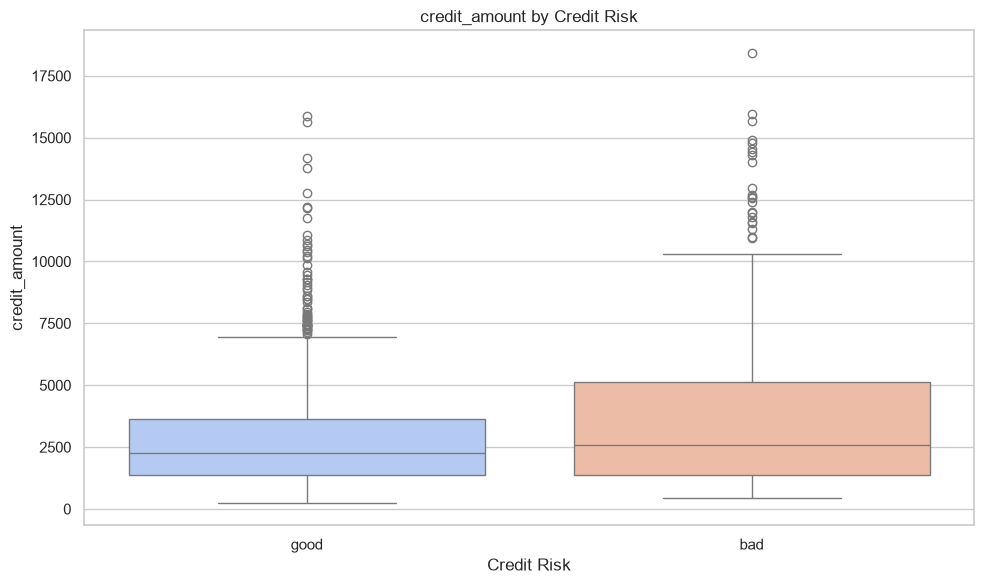

C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


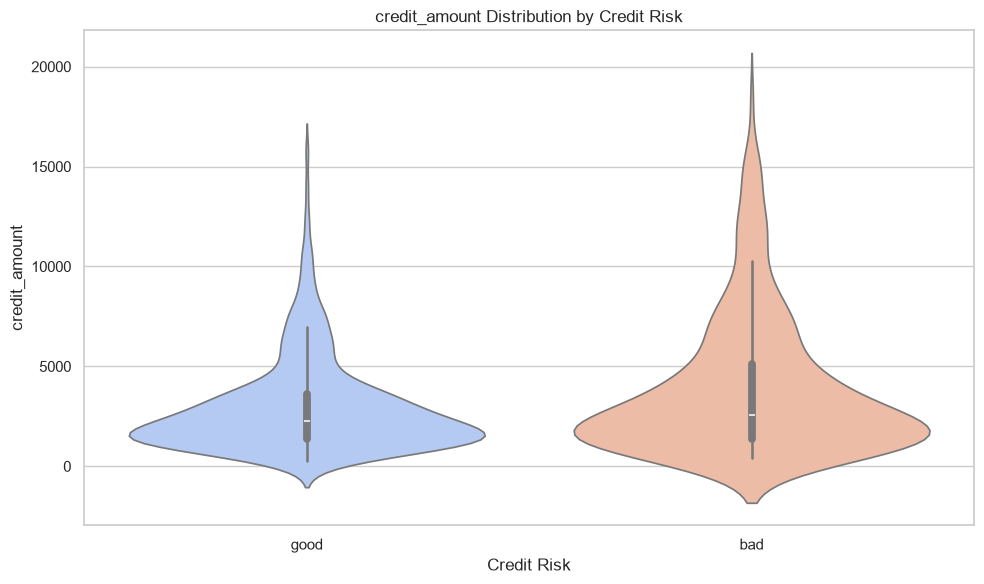

             count    mean     std    min     25%     50%     75%      max
credit_risk                                                               
bad         300.00 3938.13 3535.82 433.00 1352.50 2574.50 5141.50 18424.00
good        700.00 2985.46 2401.47 250.00 1375.50 2244.00 3634.75 15857.00


Feature: duration_months


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


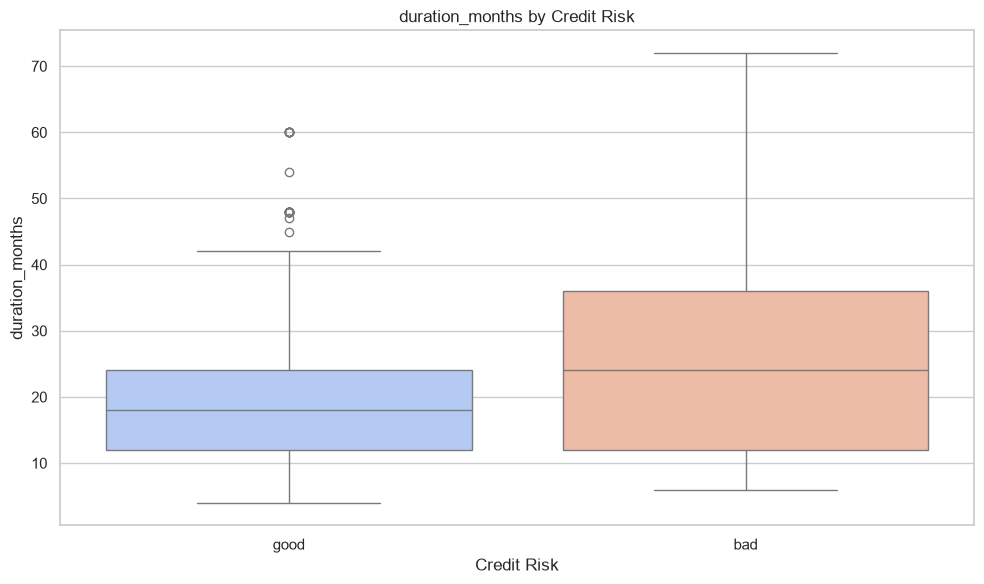

C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


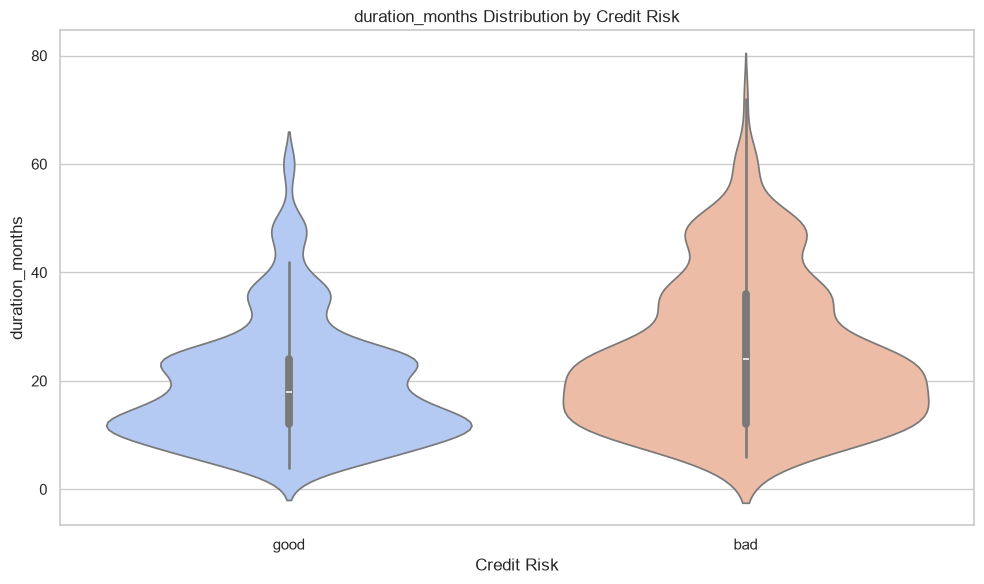

             count  mean   std  min   25%   50%   75%   max
credit_risk                                                
bad         300.00 24.86 13.28 6.00 12.00 24.00 36.00 72.00
good        700.00 19.21 11.08 4.00 12.00 18.00 24.00 60.00


Feature: existing_credits


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


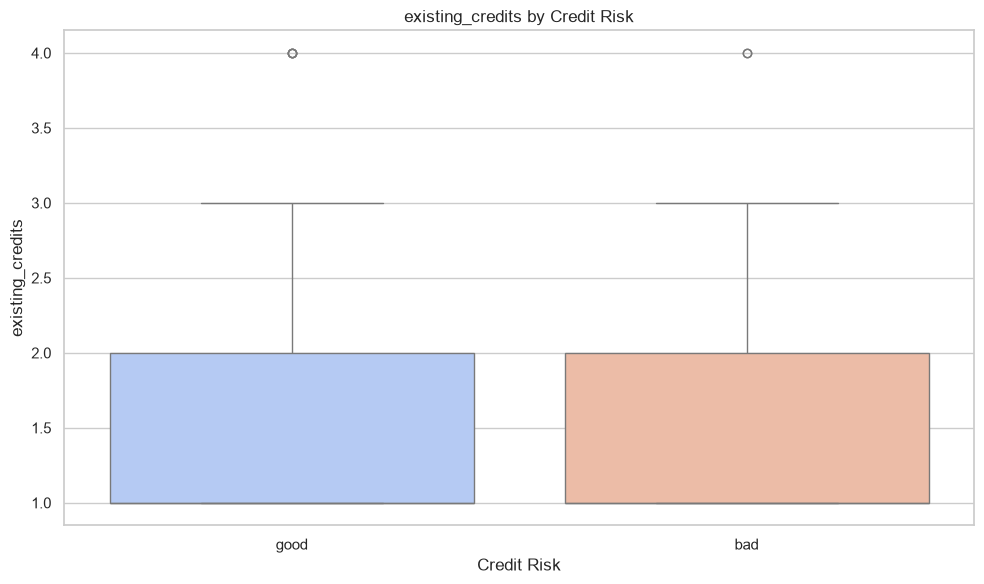

C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


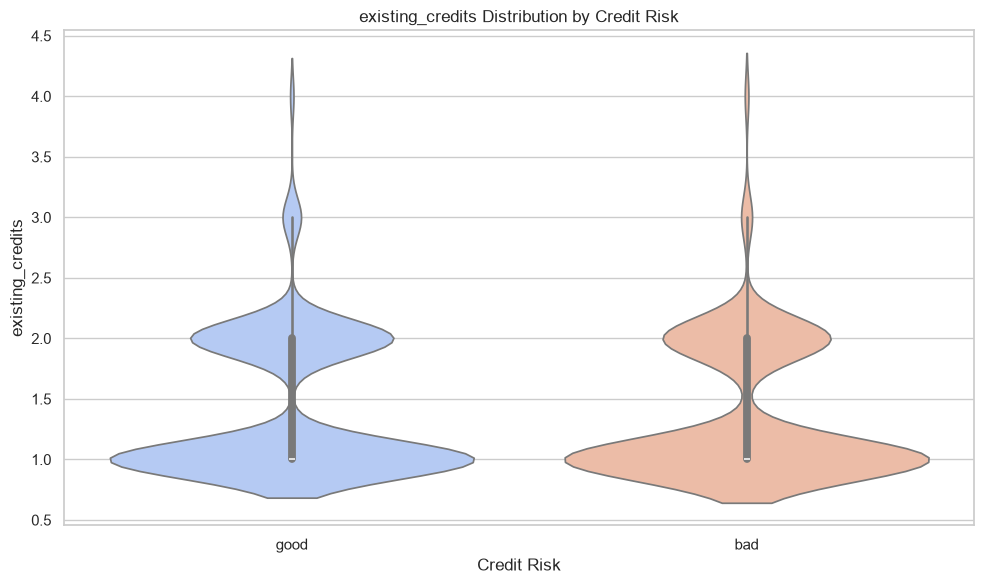

             count  mean  std  min  25%  50%  75%  max
credit_risk                                           
bad         300.00  1.37 0.56 1.00 1.00 1.00 2.00 4.00
good        700.00  1.42 0.58 1.00 1.00 1.00 2.00 4.00


Feature: installment_rate


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


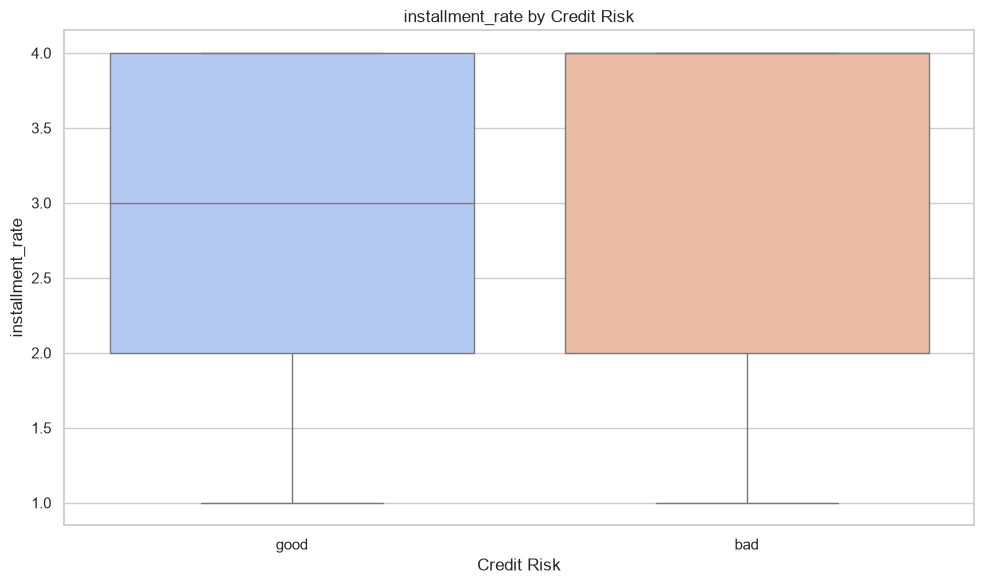

C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


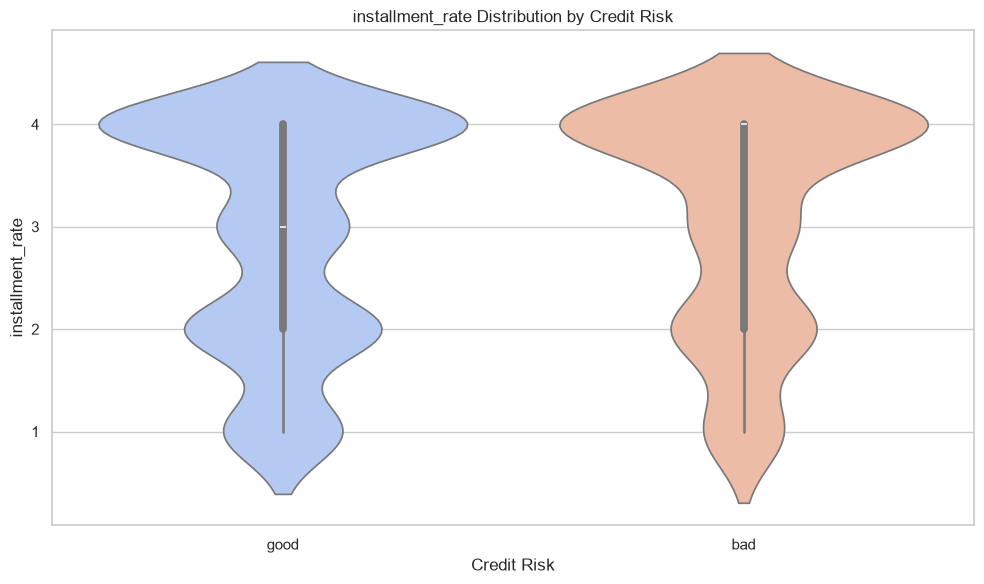

             count  mean  std  min  25%  50%  75%  max
credit_risk                                           
bad         300.00  3.10 1.09 1.00 2.00 4.00 4.00 4.00
good        700.00  2.92 1.13 1.00 2.00 3.00 4.00 4.00


Feature: people_liable


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


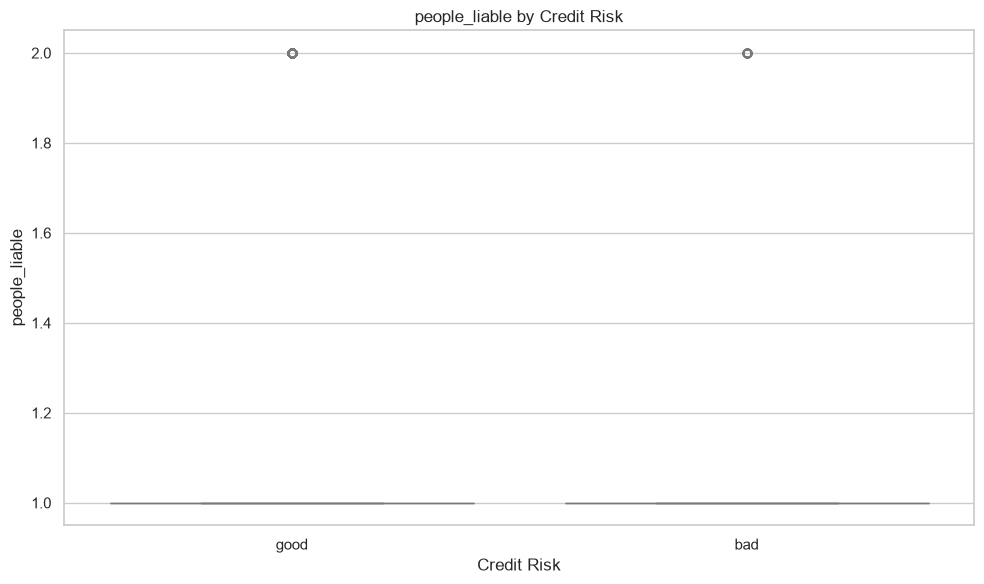

C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


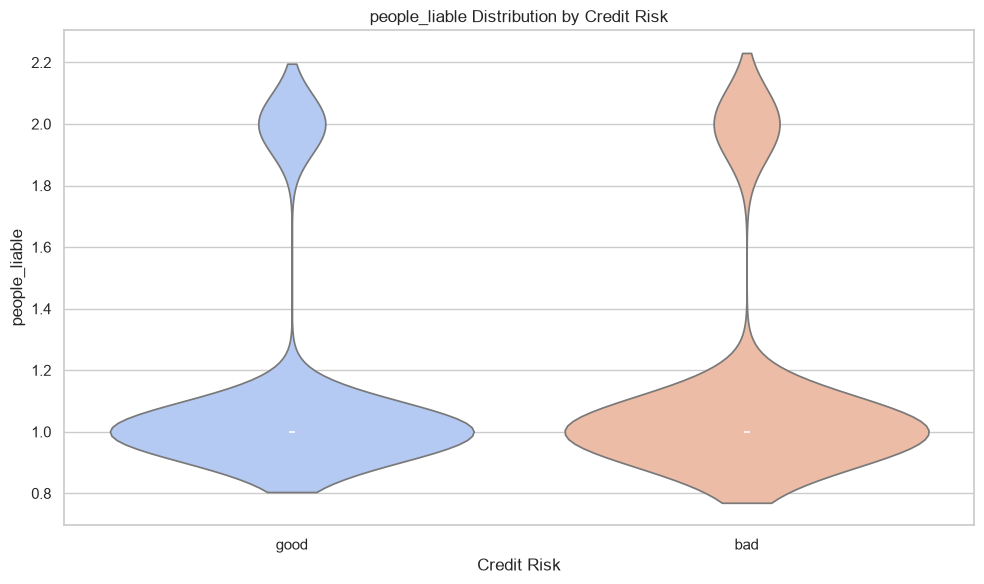

             count  mean  std  min  25%  50%  75%  max
credit_risk                                           
bad         300.00  1.15 0.36 1.00 1.00 1.00 1.00 2.00
good        700.00  1.16 0.36 1.00 1.00 1.00 1.00 2.00


Feature: present_residence_years


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


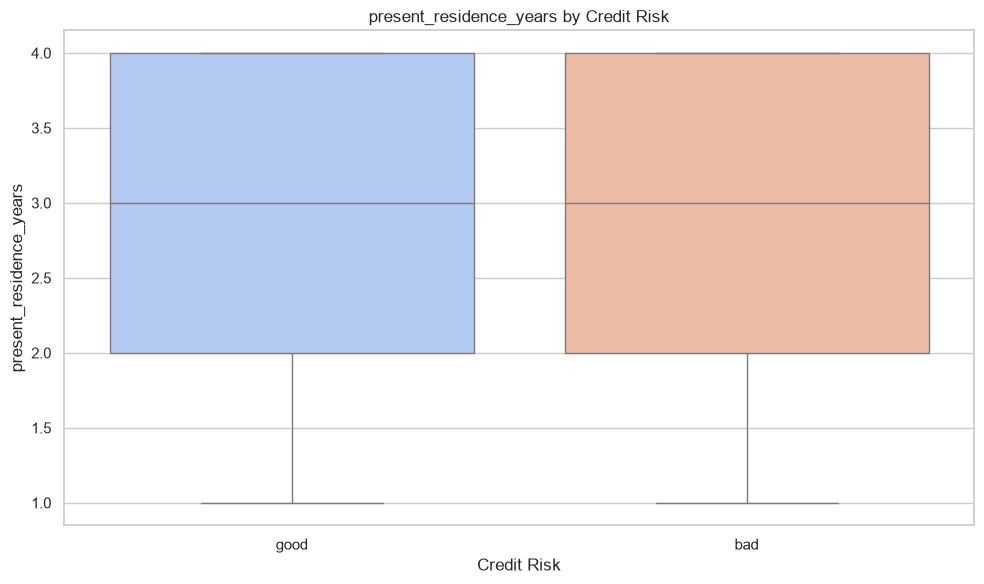

C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\2975193815.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="credit_risk", y=feature, palette="coolwarm")


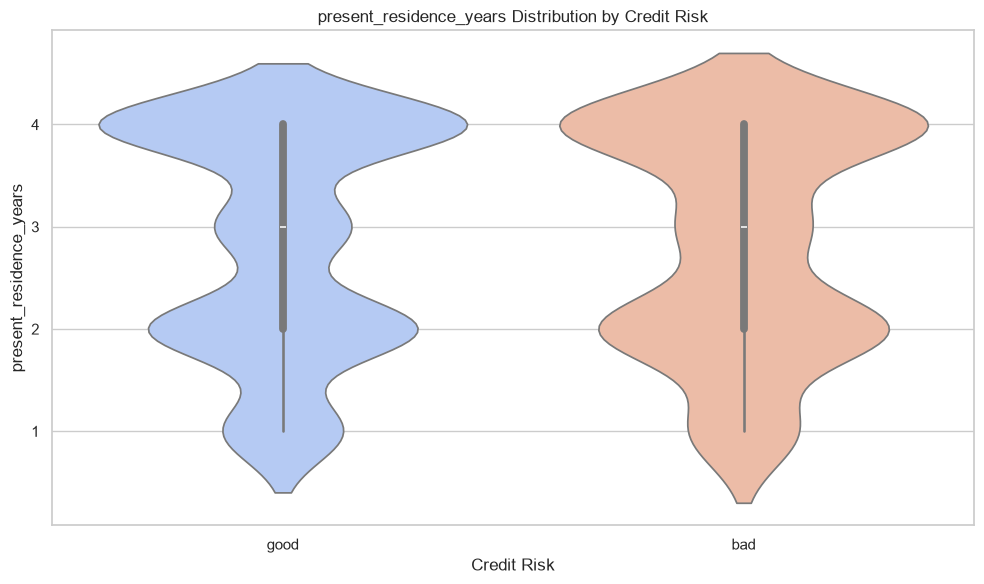

             count  mean  std  min  25%  50%  75%  max
credit_risk                                           
bad         300.00  2.85 1.09 1.00 2.00 3.00 4.00 4.00
good        700.00  2.84 1.11 1.00 2.00 3.00 4.00 4.00



In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

numerical_features = [
    "age",
    "credit_amount",
    "duration_months",
    "existing_credits",
    "installment_rate",
    "people_liable",
    "present_residence_years",
]

for feature in numerical_features:
    print(f"\n{'=' * 60}\nFeature: {feature}\n{'=' * 60}")

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="credit_risk", y=feature, palette="coolwarm")
    plt.title(f"{feature} by Credit Risk")
    plt.xlabel("Credit Risk")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x="credit_risk", y=feature, palette="coolwarm")
    plt.title(f"{feature} Distribution by Credit Risk")
    plt.xlabel("Credit Risk")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

    print(df.groupby("credit_risk")[feature].describe().round(2))
    print()

## 7.2 Categorical Features vs Credit Risk


Feature: checking_account_status


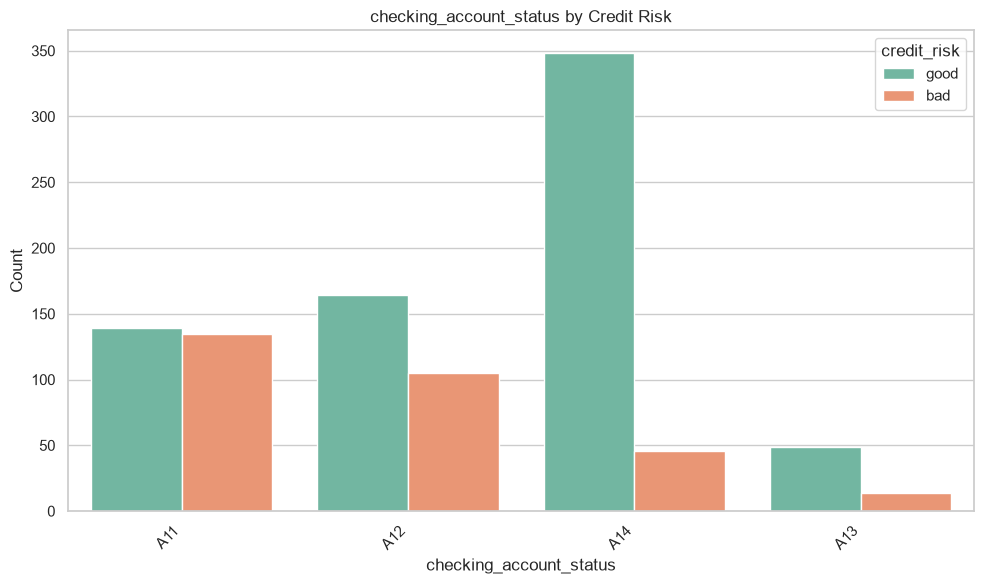

credit_risk              bad  good
checking_account_status           
A11                      135   139
A12                      105   164
A13                       14    49
A14                       46   348

Row-wise percentages:
credit_risk              bad  good
checking_account_status           
A11                     0.49  0.51
A12                     0.39  0.61
A13                     0.22  0.78
A14                     0.12  0.88


Feature: credit_history


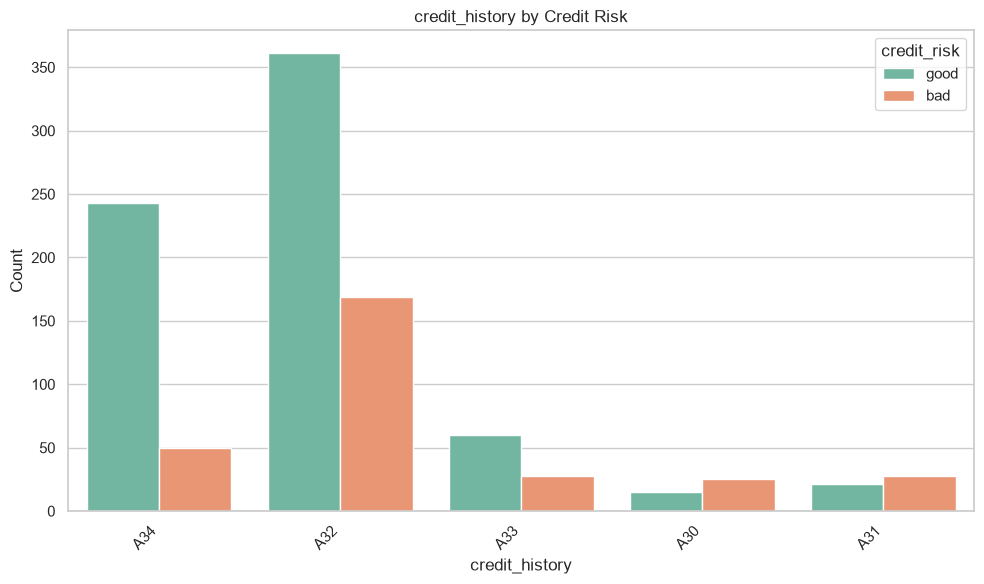

credit_risk     bad  good
credit_history           
A30              25    15
A31              28    21
A32             169   361
A33              28    60
A34              50   243

Row-wise percentages:
credit_risk     bad  good
credit_history           
A30            0.62  0.38
A31            0.57  0.43
A32            0.32  0.68
A33            0.32  0.68
A34            0.17  0.83


Feature: purpose


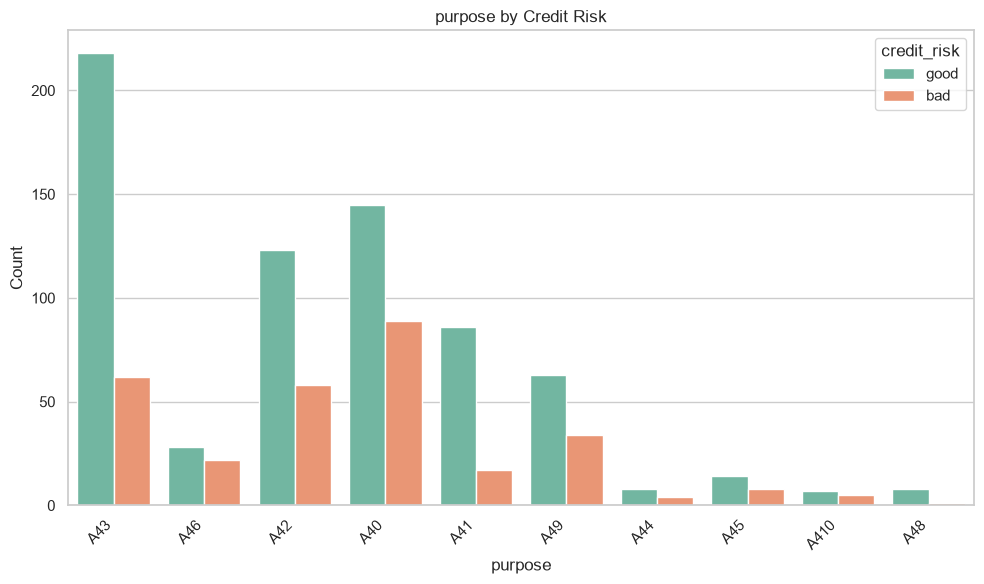

credit_risk  bad  good
purpose               
A40           89   145
A41           17    86
A410           5     7
A42           58   123
A43           62   218
A44            4     8
A45            8    14
A46           22    28
A48            1     8
A49           34    63

Row-wise percentages:
credit_risk  bad  good
purpose               
A40         0.38  0.62
A41         0.17  0.83
A410        0.42  0.58
A42         0.32  0.68
A43         0.22  0.78
A44         0.33  0.67
A45         0.36  0.64
A46         0.44  0.56
A48         0.11  0.89
A49         0.35  0.65


Feature: savings_account


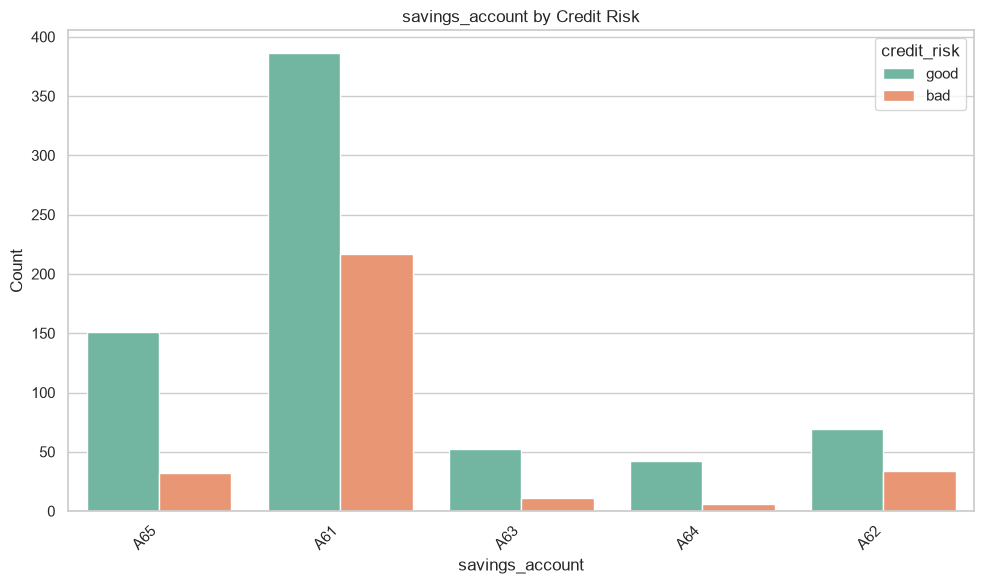

credit_risk      bad  good
savings_account           
A61              217   386
A62               34    69
A63               11    52
A64                6    42
A65               32   151

Row-wise percentages:
credit_risk      bad  good
savings_account           
A61             0.36  0.64
A62             0.33  0.67
A63             0.17  0.83
A64             0.12  0.88
A65             0.17  0.83


Feature: employment_duration


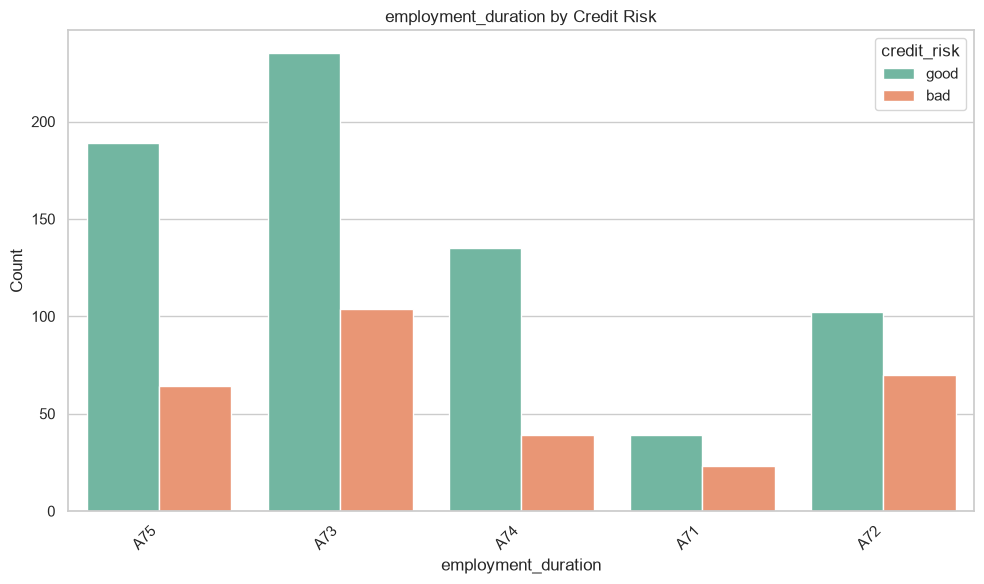

credit_risk          bad  good
employment_duration           
A71                   23    39
A72                   70   102
A73                  104   235
A74                   39   135
A75                   64   189

Row-wise percentages:
credit_risk          bad  good
employment_duration           
A71                 0.37  0.63
A72                 0.41  0.59
A73                 0.31  0.69
A74                 0.22  0.78
A75                 0.25  0.75


Feature: personal_status_sex


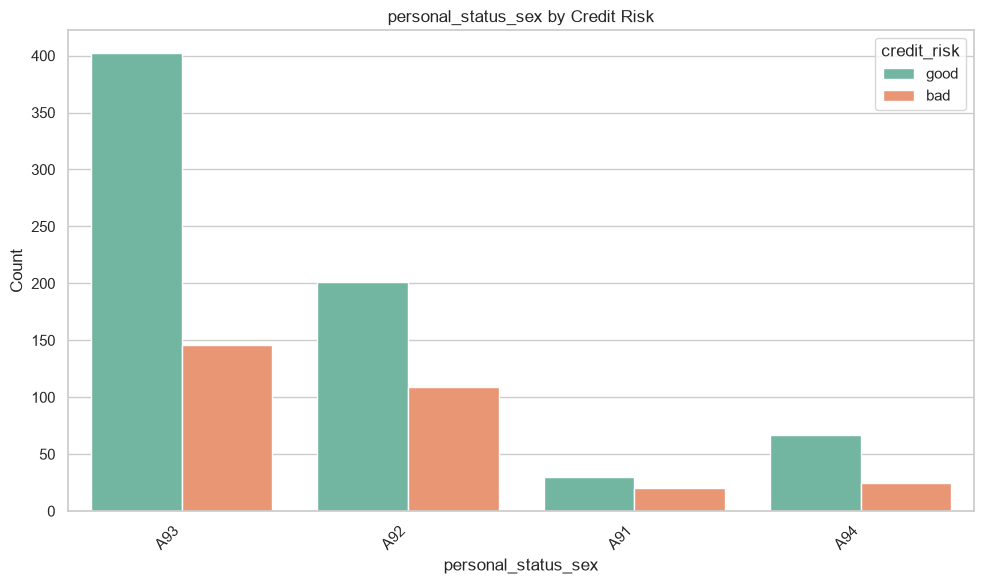

credit_risk          bad  good
personal_status_sex           
A91                   20    30
A92                  109   201
A93                  146   402
A94                   25    67

Row-wise percentages:
credit_risk          bad  good
personal_status_sex           
A91                 0.40  0.60
A92                 0.35  0.65
A93                 0.27  0.73
A94                 0.27  0.73


Feature: other_debtors


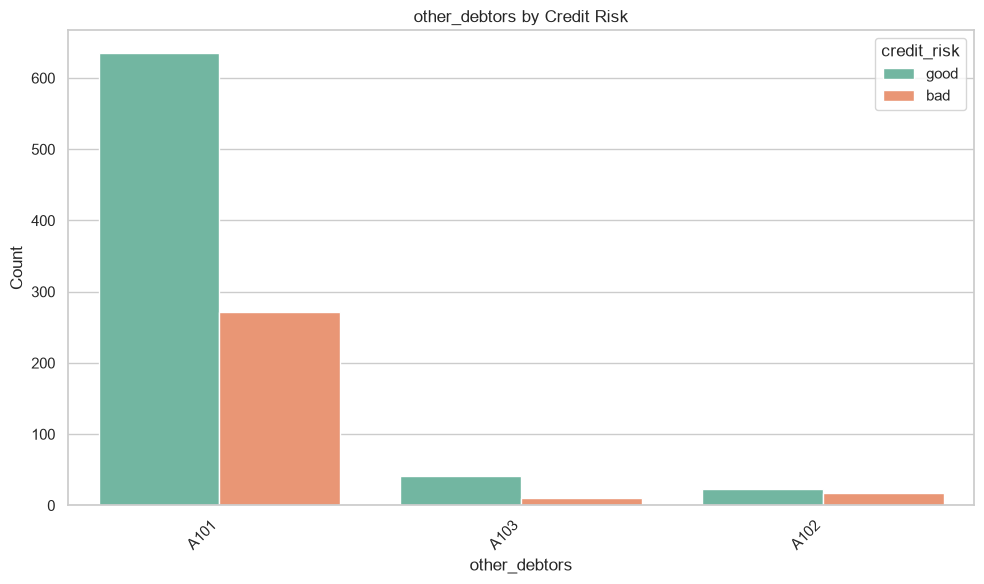

credit_risk    bad  good
other_debtors           
A101           272   635
A102            18    23
A103            10    42

Row-wise percentages:
credit_risk    bad  good
other_debtors           
A101          0.30  0.70
A102          0.44  0.56
A103          0.19  0.81


Feature: property


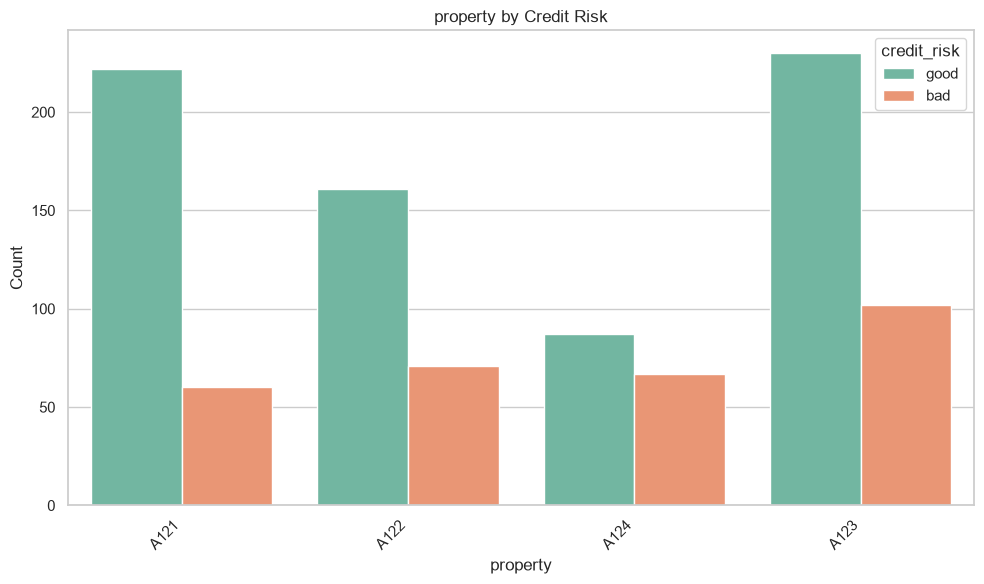

credit_risk  bad  good
property              
A121          60   222
A122          71   161
A123         102   230
A124          67    87

Row-wise percentages:
credit_risk  bad  good
property              
A121        0.21  0.79
A122        0.31  0.69
A123        0.31  0.69
A124        0.44  0.56


Feature: other_installment_plans


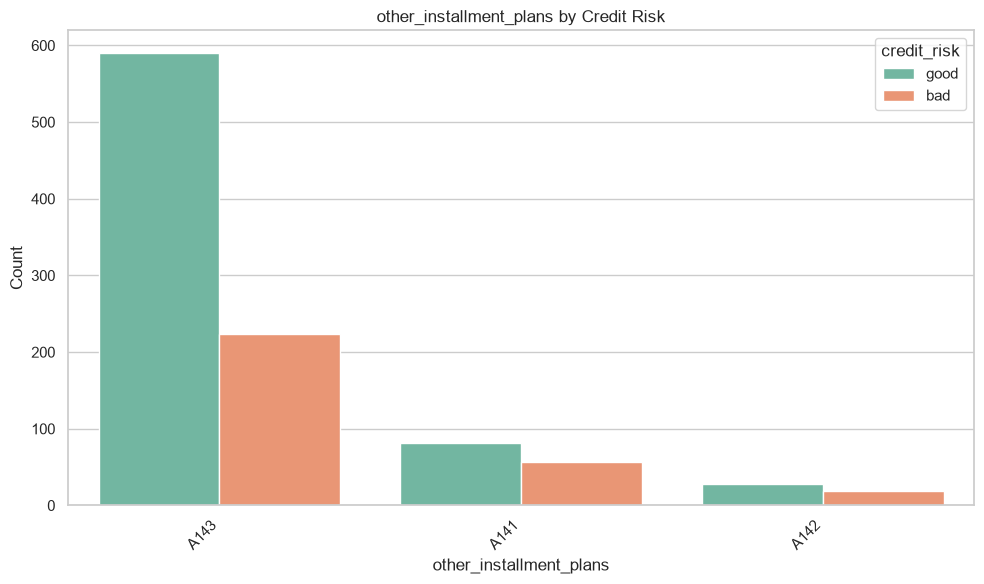

credit_risk              bad  good
other_installment_plans           
A141                      57    82
A142                      19    28
A143                     224   590

Row-wise percentages:
credit_risk              bad  good
other_installment_plans           
A141                    0.41  0.59
A142                    0.40  0.60
A143                    0.28  0.72


Feature: housing


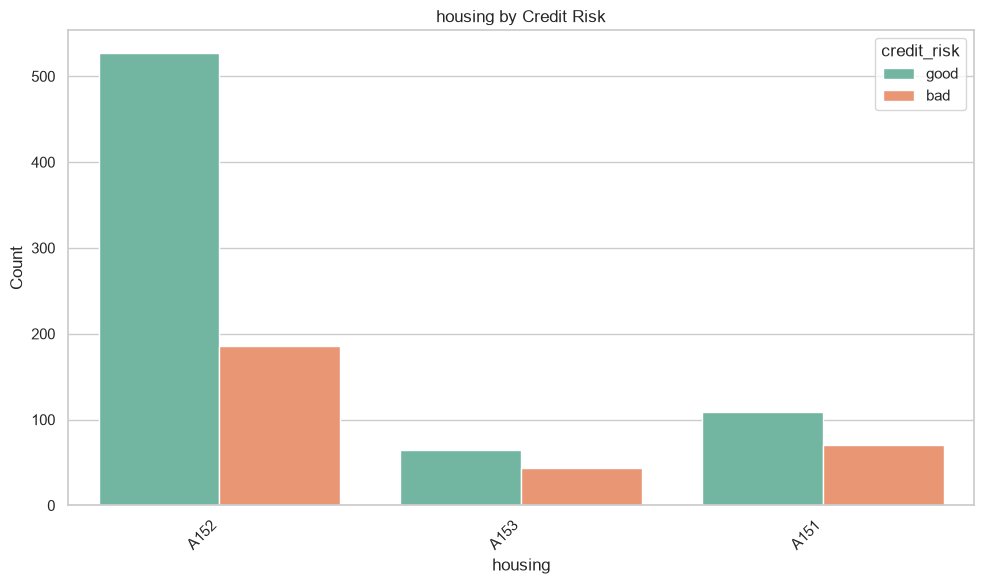

credit_risk  bad  good
housing               
A151          70   109
A152         186   527
A153          44    64

Row-wise percentages:
credit_risk  bad  good
housing               
A151        0.39  0.61
A152        0.26  0.74
A153        0.41  0.59


Feature: job


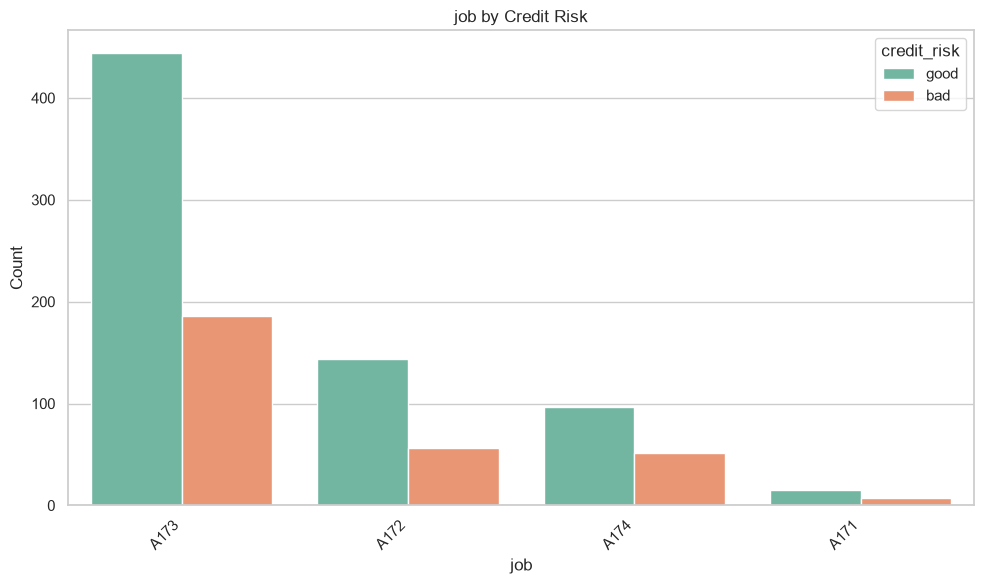

credit_risk  bad  good
job                   
A171           7    15
A172          56   144
A173         186   444
A174          51    97

Row-wise percentages:
credit_risk  bad  good
job                   
A171        0.32  0.68
A172        0.28  0.72
A173        0.30  0.70
A174        0.34  0.66


Feature: telephone


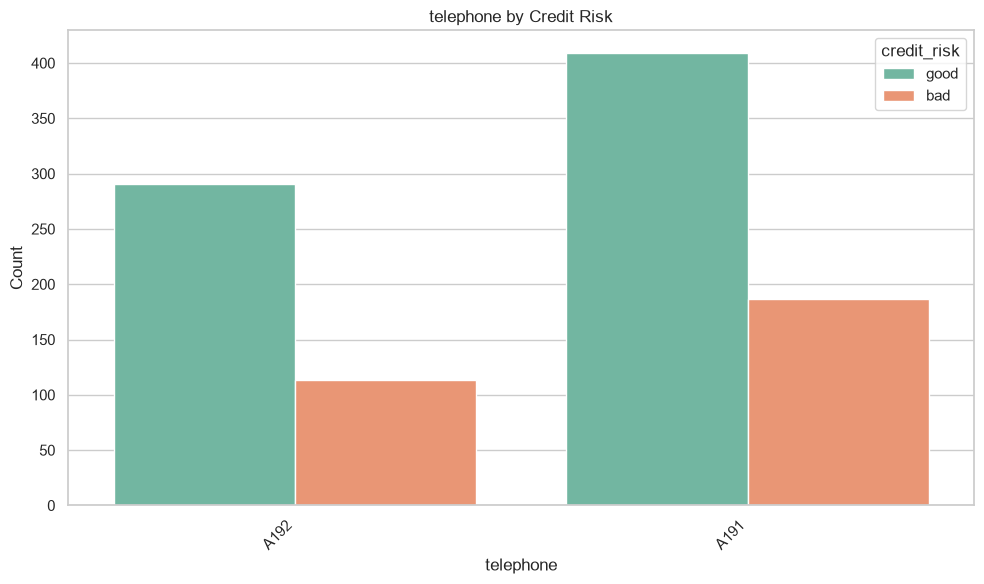

credit_risk  bad  good
telephone             
A191         187   409
A192         113   291

Row-wise percentages:
credit_risk  bad  good
telephone             
A191        0.31  0.69
A192        0.28  0.72


Feature: foreign_worker


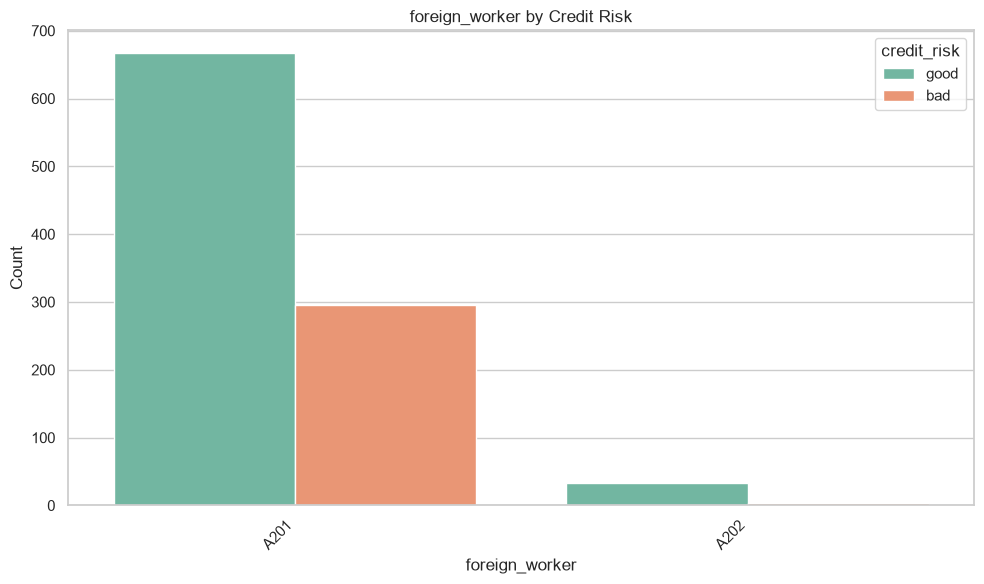

credit_risk     bad  good
foreign_worker           
A201            296   667
A202              4    33

Row-wise percentages:
credit_risk     bad  good
foreign_worker           
A201           0.31  0.69
A202           0.11  0.89



In [13]:
categorical_features = [
    "checking_account_status",
    "credit_history",
    "purpose",
    "savings_account",
    "employment_duration",
    "personal_status_sex",
    "other_debtors",
    "property",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker",
]

for feature in categorical_features:
    print(f"\n{'=' * 60}\nFeature: {feature}\n{'=' * 60}")

    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=feature, hue="credit_risk", palette="Set2")
    plt.title(f"{feature} by Credit Risk")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print(pd.crosstab(df[feature], df["credit_risk"]))
    print("\nRow-wise percentages:")
    print(pd.crosstab(df[feature], df["credit_risk"], normalize="index").round(2))
    print()

## 7.3 Correlation Analysis

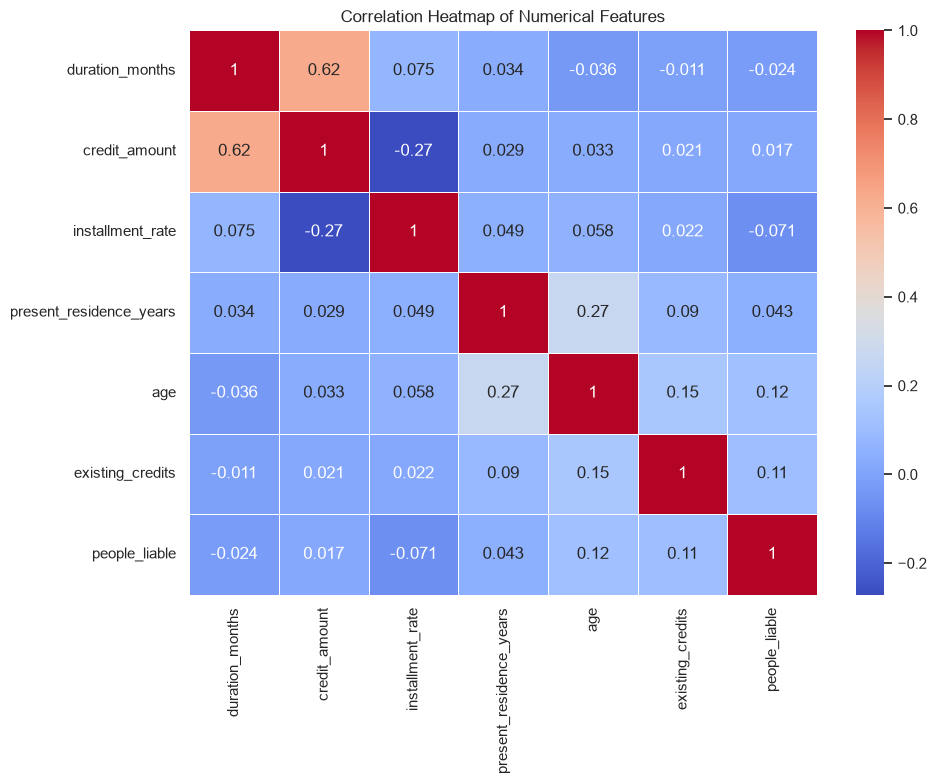

In [14]:
numeric_df = df.select_dtypes(include=["number"])
correlation = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## 7.4 Pairplot

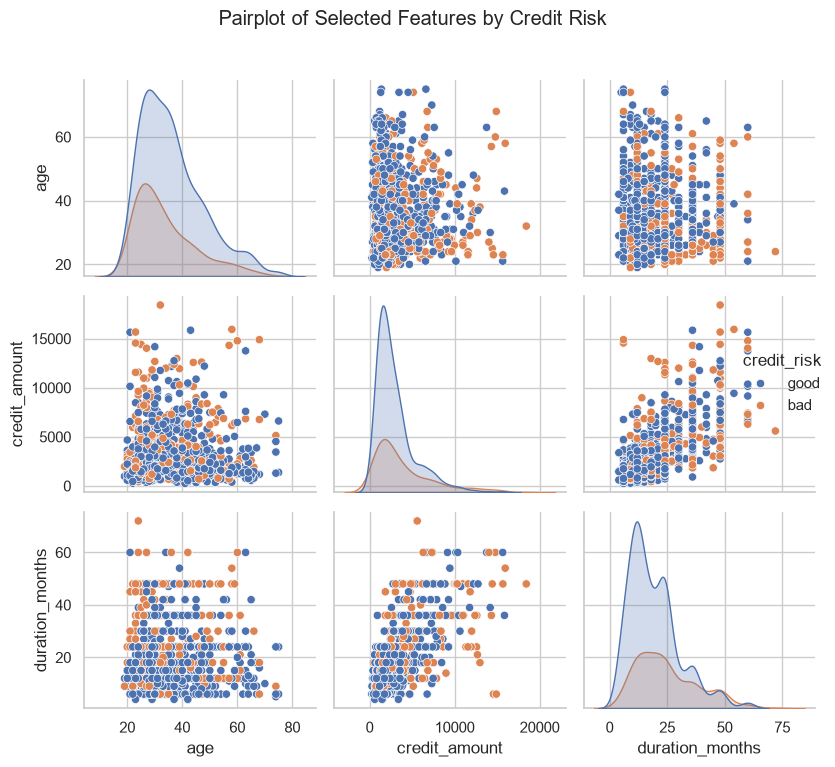

In [15]:
pairplot_variables = ["age", "credit_amount", "duration_months"]
pairplot = sns.pairplot(df[pairplot_variables + ["credit_risk"]], hue="credit_risk", height=2.5)
pairplot.fig.suptitle("Pairplot of Selected Features by Credit Risk", y=1.02)
pairplot.fig.tight_layout()
plt.show()

## Key Findings

- The boxplots and violin plots help compare the spread and central tendency of each numeric feature across the credit-risk groups.
- The categorical count plots and contingency tables show how category proportions differ between good and bad credit outcomes.
- The correlation heatmap highlights the relative strength of relationships among the numerical variables.